In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths from your project structure
nhanes_filepath = 'data/03_processed/nhanes_final.csv'
brfss_filepath = 'data/03_processed/brfss_final.csv'

# Column names for the 8 common predictors, based on your list
nhanes_cols = {
    'age': 'Age',
    'gender': 'Gender',
    'race': 'Race_Ethnicity',
    'bmi': 'BMI',
    'smoking': 'Smoking_Status',
    'activity': 'Physical_Activity',
    'heart_attack': 'History_Heart_Attack',
    'stroke': 'History_Stroke',
    'diabetes': 'Diabetes_Outcome'
}

brfss_cols = {
    'age': 'Age',
    'gender': 'Gender',
    'race': 'Race_Ethnicity',
    'bmi': 'BMI',
    'smoking': 'Smoking_Status',
    'activity': 'Physical_Activity',
    'heart_attack': 'History_Heart_Attack',
    'stroke': 'History_Stroke',
    'diabetes': 'Diabetes_Outcome'
}

# --- DATA LOADING AND STANDARDIZATION ---
try:
    df_nhanes = pd.read_csv(nhanes_filepath, usecols=list(nhanes_cols.values()))
    df_brfss = pd.read_csv(brfss_filepath, usecols=list(brfss_cols.values()))
    
    df_nhanes = df_nhanes.rename(columns={v: k for k, v in nhanes_cols.items()})
    df_brfss = df_brfss.rename(columns={v: k for k, v in brfss_cols.items()})

    df_nhanes['source'] = 'NHANES (Development)'
    df_brfss['source'] = 'BRFSS (External Validation)'

    combined_df = pd.concat([df_nhanes, df_brfss], ignore_index=True)
    
    print("Successfully loaded and combined datasets!")
    print(f"NHANES shape: {df_nhanes.shape}")
    print(f"BRFSS shape: {df_brfss.shape}")

except FileNotFoundError as e:
    print(f"Error: Could not find the file at {e.filename}. Make sure you are running this script from the root directory of your project.")
except KeyError as e:
    print(f"Error: A column name was not found: {e}. Please check your column name dictionaries.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

: 

Generating Figure 2: Feature Distribution Comparison (Publication Quality)...
Successfully loaded and combined datasets.


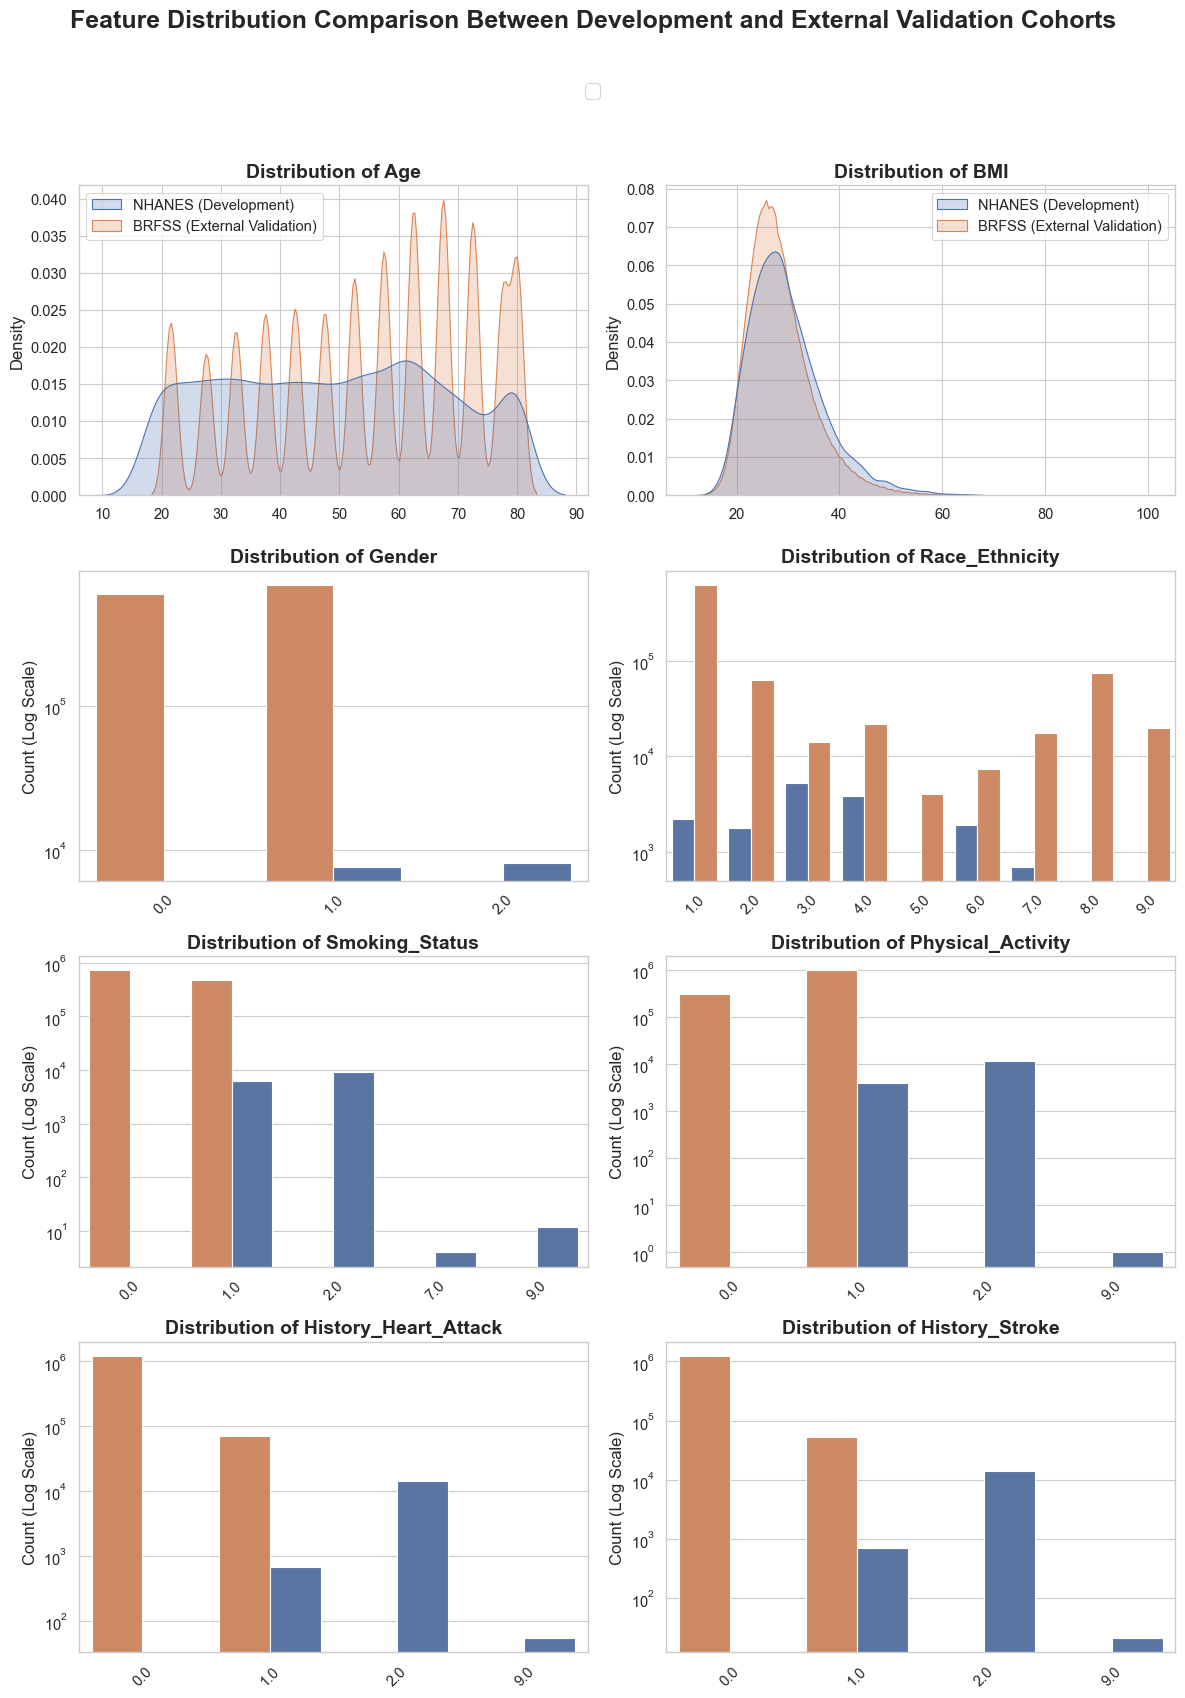


Publication-quality Figure 2 has been successfully saved to: ../reports\Figure_2_Feature_Distributions.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generating Figure 2: Feature Distribution Comparison (Publication Quality)...")

# --- 1. Setup for Publication-Quality Plotting ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# --- 2. Load and Prepare Datasets ---
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
df_nhanes = pd.read_csv(nhanes_filepath)
df_brfss = pd.read_csv(brfss_filepath)
df_nhanes['source'] = 'NHANES (Development)'
df_brfss['source'] = 'BRFSS (External Validation)'
combined_df = pd.concat([df_nhanes, df_brfss], ignore_index=True)
print("Successfully loaded and combined datasets.")

# --- 3. Define Feature Lists and Plotting Properties ---
continuous_features = ['Age', 'BMI']
categorical_features = [
    'Gender', 'Race_Ethnicity', 'Smoking_Status', 
    'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'
]
palette = {'NHANES (Development)': '#4C72B0', 'BRFSS (External Validation)': '#DD8452'}

# --- 4. Create the Multi-Panel Figure ---
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

# Plot Continuous Variables
for i, feature in enumerate(continuous_features):
    ax = axes[i]
    sns.kdeplot(data=combined_df, x=feature, hue='source', fill=True, 
                common_norm=False, ax=ax, palette=palette)
    ax.set_title(f'Distribution of {feature}', fontsize=14, weight='bold')
    ax.set_xlabel(None); ax.set_ylabel('Density', fontsize=12)
    ax.get_legend().set_title(None)

# Plot Categorical Variables
for i, feature in enumerate(categorical_features):
    ax_idx = i + len(continuous_features)
    ax = axes[ax_idx]
    sns.countplot(data=combined_df, x=feature, hue='source', ax=ax, palette=palette)
    ax.set_title(f'Distribution of {feature}', fontsize=14, weight='bold')
    ax.set_xlabel(None); ax.set_ylabel('Count (Log Scale)', fontsize=12)
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=45)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# --- 5. Final Touches and Export (CORRECTED PATH) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=14)
fig.suptitle('Feature Distribution Comparison Between Development and External Validation Cohorts', fontsize=18, weight='bold', y=1.06)
plt.tight_layout(rect=[0, 0, 1, 1])

# --- THIS IS THE CORRECTED PART ---
# The '../' tells Python to go "up" one folder before finding 'reports'
output_dir = '../reports' 
os.makedirs(output_dir, exist_ok=True) # This is safe, it does nothing if the folder exists

output_path = os.path.join(output_dir, 'Figure_2_Feature_Distributions.png')
# --- END OF CORRECTION ---

plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPublication-quality Figure 2 has been successfully saved to: {output_path}")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Setting up for individual plot generation...")

# --- 1. Setup for Publication-Quality Plotting ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5) # Increased font scale for individual plots

# --- 2. Load and Prepare Datasets ---
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'

df_nhanes = pd.read_csv(nhanes_filepath)
df_brfss = pd.read_csv(brfss_filepath)

df_nhanes['source'] = 'NHANES (Development)'
df_brfss['source'] = 'BRFSS (External Validation)'

combined_df = pd.concat([df_nhanes, df_brfss], ignore_index=True)
print("Successfully loaded and combined datasets.")

# --- 3. Define Plotting Properties ---
palette = {'NHANES (Development)': '#4C72B0', 'BRFSS (External Validation)': '#DD8452'}

# --- 4. Create the output directory ---
# The '../' tells Python to go "up" one folder before finding 'reports'
output_dir = '../reports/Figure_2_Panels' 
os.makedirs(output_dir, exist_ok=True) # This creates a dedicated subfolder

print(f"Setup complete. Figures will be saved in the '{output_dir}' folder.")

Setting up for individual plot generation...
Successfully loaded and combined datasets.
Setup complete. Figures will be saved in the '../reports/Figure_2_Panels' folder.


C:\Users\Asus\AppData\Local\Temp\ipykernel_6644\3239835462.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=None)


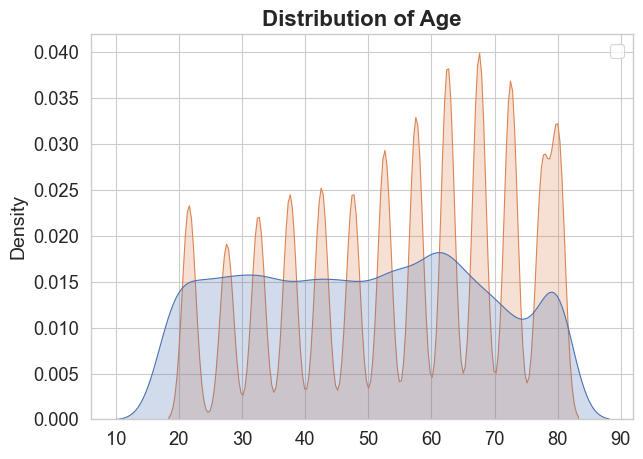

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_A_Age.png


In [12]:
feature = 'Age'
plt.figure(figsize=(7, 5))
ax = sns.kdeplot(data=combined_df, x=feature, hue='source', fill=True, common_norm=False, palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Density', fontsize=14)
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_A_Age.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

C:\Users\Asus\AppData\Local\Temp\ipykernel_6644\1993818170.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=None)


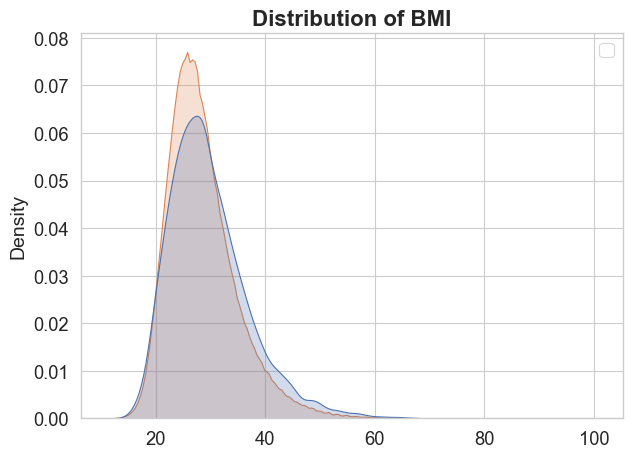

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_B_BMI.png


In [13]:
feature = 'BMI'
plt.figure(figsize=(7, 5))
ax = sns.kdeplot(data=combined_df, x=feature, hue='source', fill=True, common_norm=False, palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Density', fontsize=14)
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_B_BMI.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

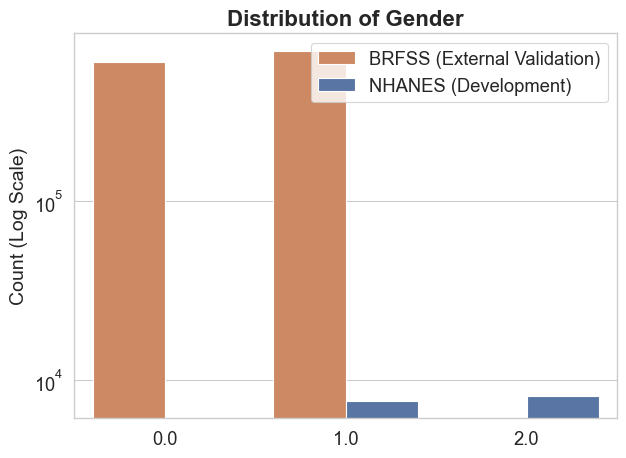

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_C_Gender.png


In [14]:

feature = 'Gender'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=combined_df, x=feature, hue='source', palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Count (Log Scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_C_Gender.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

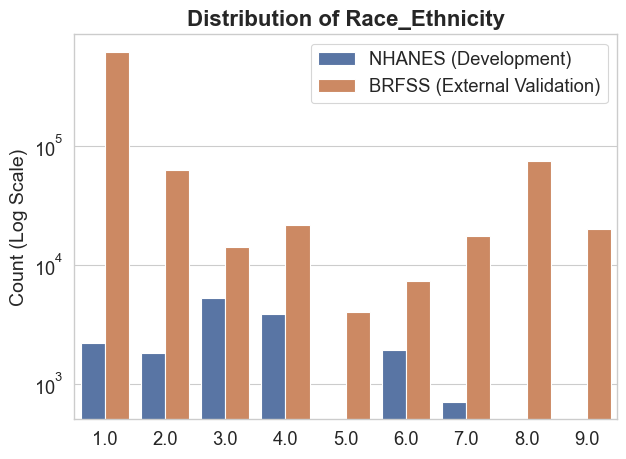

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_D_Race.png


In [15]:
feature = 'Race_Ethnicity'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=combined_df, x=feature, hue='source', palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Count (Log Scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_D_Race.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

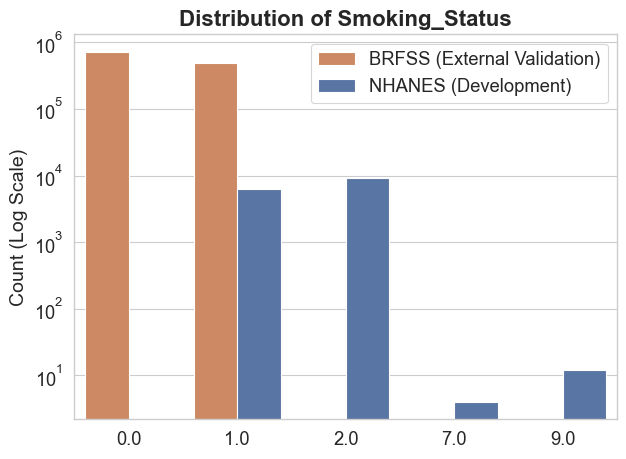

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_E_Smoking.png


In [16]:
feature = 'Smoking_Status'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=combined_df, x=feature, hue='source', palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Count (Log Scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_E_Smoking.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

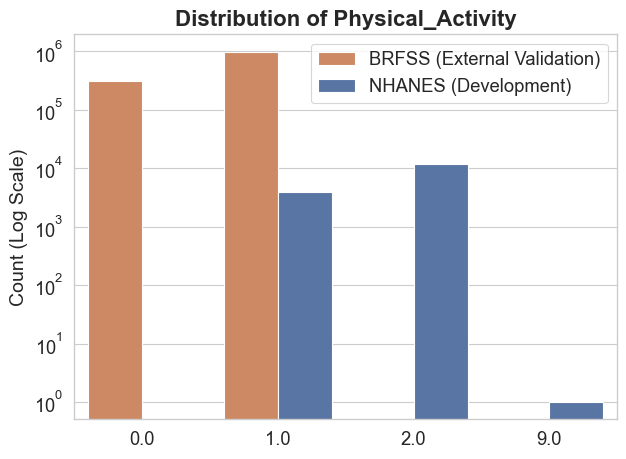

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_F_Activity.png


In [17]:
feature = 'Physical_Activity'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=combined_df, x=feature, hue='source', palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Count (Log Scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_F_Activity.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

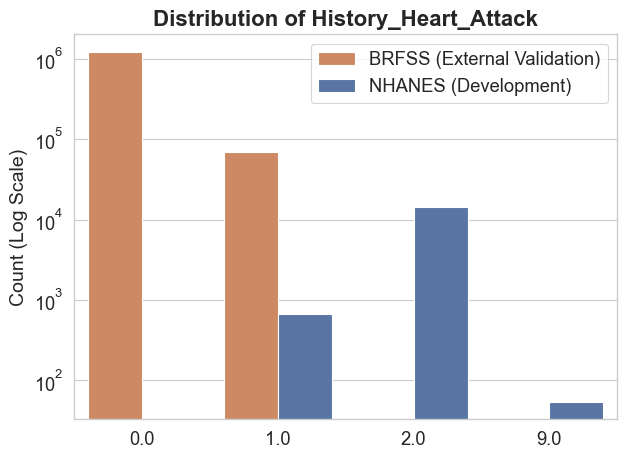

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_G_HeartAttack.png


In [18]:
feature = 'History_Heart_Attack'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=combined_df, x=feature, hue='source', palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Count (Log Scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_G_HeartAttack.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

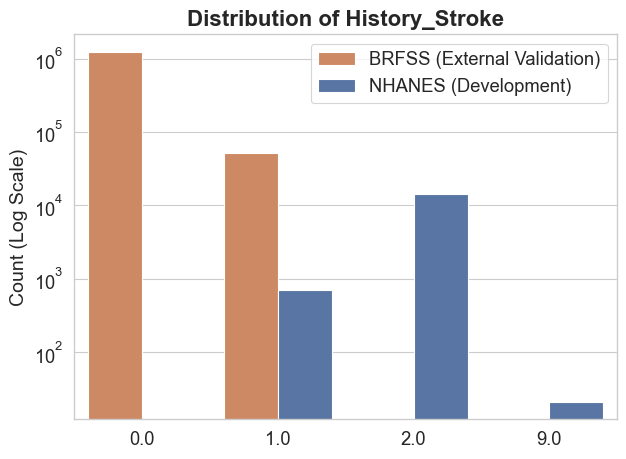

Saved: ../reports/Figure_2_Panels\Figure_2_Panel_H_Stroke.png


In [19]:
feature = 'History_Stroke'
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=combined_df, x=feature, hue='source', palette=palette)
ax.set_title(f'Distribution of {feature}', fontsize=16, weight='bold')
ax.set_xlabel(None)
ax.set_ylabel('Count (Log Scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(title=None)

output_path = os.path.join(output_dir, 'Figure_2_Panel_H_Stroke.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")

Generating Figure 3: ROC Curves (Publication Quality)...
Successfully loaded internal and external prediction files.


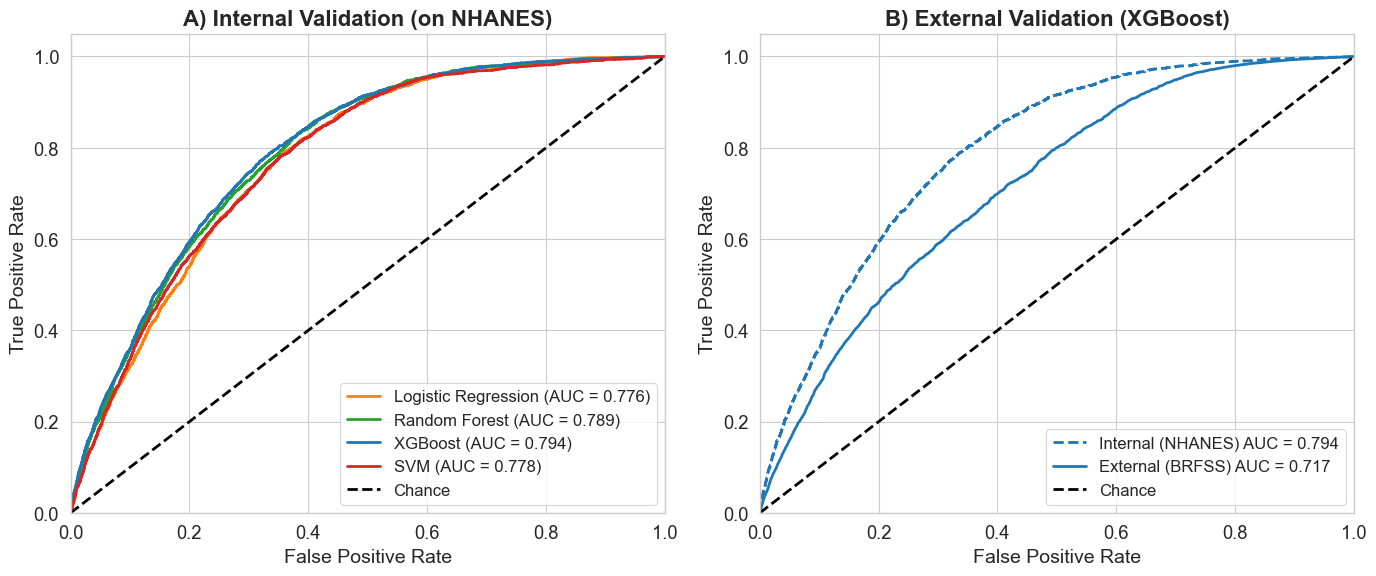


Publication-quality Figure 3 has been successfully saved to: ../reports\Figure_3_ROC_Curves.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import os

print("Generating Figure 3: ROC Curves (Publication Quality)...")

# --- 1. Setup for Publication-Quality Plotting ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# --- 2. Load the Prediction Data (with error checking) ---
try:
    # Using absolute paths for robustness
    internal_preds_path = r'C:\diabetes_prediction_project\notebooks\results\internal_validation_predictions.csv'
    external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
    
    df_internal = pd.read_csv(internal_preds_path)
    df_external = pd.read_csv(external_preds_path)
    print("Successfully loaded internal and external prediction files.")

except FileNotFoundError as e:
    print(f"FATAL ERROR: Could not find a required prediction file. {e}")
    print("Please ensure you have run the updated '02_model_training.ipynb' and '03_external_validation.ipynb' notebooks to generate the prediction files.")
    # We will stop the script here if files are missing
    # In a notebook, this will prevent the rest of the cell from running.
    raise e

# --- 3. Create the Two-Panel Figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_colors = {
    'XGBoost': '#1f77b4',
    'Logistic Regression': '#ff7f0e',
    'Random Forest': '#2ca02c',
    'SVM': '#d62728'
}

# --- Panel A: Internal Validation Comparison ---
ax = axes[0]
for model_name in df_internal['model'].unique():
    model_df = df_internal[df_internal['model'] == model_name]
    y_true = model_df['y_true']
    y_pred_proba = model_df['y_pred_proba']
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color=model_colors.get(model_name), lw=2, 
            label=f'{model_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('A) Internal Validation (on NHANES)', fontsize=16, weight='bold')
ax.legend(loc="lower right", fontsize=12)
ax.grid(True)

# --- Panel B: External Validation Performance Drop ---
ax = axes[1]

xgb_internal_df = df_internal[df_internal['model'] == 'XGBoost']
fpr_internal, tpr_internal, _ = roc_curve(xgb_internal_df['y_true'], xgb_internal_df['y_pred_proba'])
auc_internal = auc(fpr_internal, tpr_internal)
ax.plot(fpr_internal, tpr_internal, color=model_colors['XGBoost'], lw=2, linestyle='--',
        label=f'Internal (NHANES) AUC = {auc_internal:.3f}')

fpr_external, tpr_external, _ = roc_curve(df_external['y_true'], df_external['y_pred_proba'])
auc_external = auc(fpr_external, tpr_external)
ax.plot(fpr_external, tpr_external, color=model_colors['XGBoost'], lw=2, linestyle='-',
        label=f'External (BRFSS) AUC = {auc_external:.3f}')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('B) External Validation (XGBoost)', fontsize=16, weight='bold')
ax.legend(loc="lower right", fontsize=12)
ax.grid(True)

# --- 4. Final Touches and Export ---
plt.tight_layout()

# Correctly go up one directory to find the 'reports' folder
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True) 

output_path = os.path.join(output_dir, 'Figure_3_ROC_Curves.png')
plt.savefig(output_path, dpi=600, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 3 has been successfully saved to: {output_path}")

Generating separate, high-resolution ROC Curve figures...
Successfully loaded prediction files.


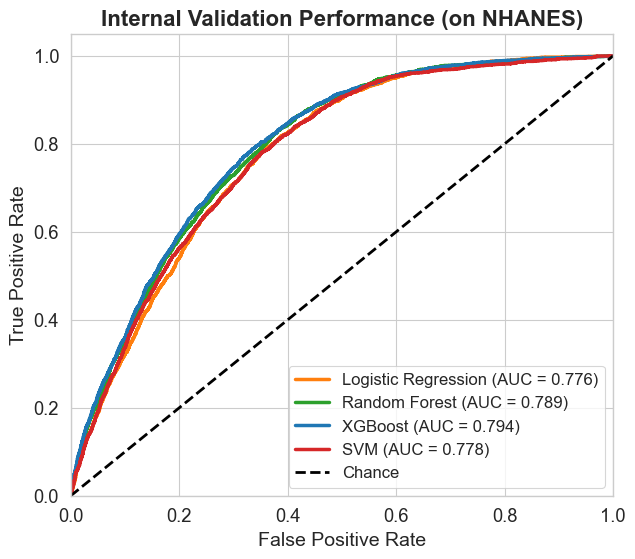

Saved Panel A to: ../reports\Figure_3A_Internal_Validation.png


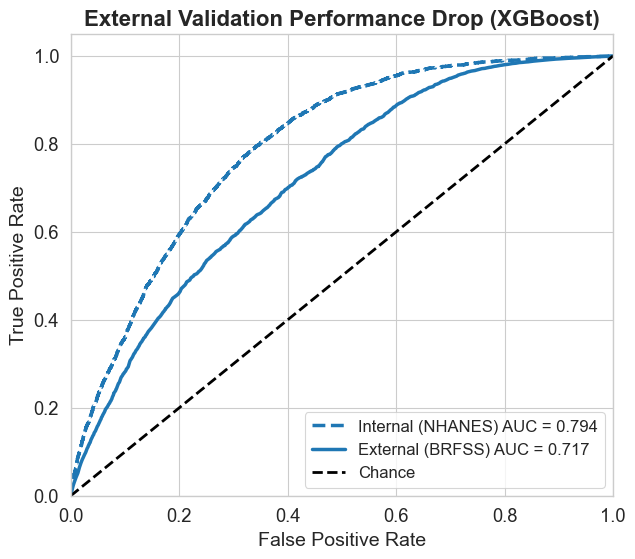

Saved Panel B to: ../reports\Figure_3B_External_Validation.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import os

print("Generating separate, high-resolution ROC Curve figures...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)
internal_preds_path = r'C:\diabetes_prediction_project\notebooks\results\internal_validation_predictions.csv'
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_internal = pd.read_csv(internal_preds_path)
df_external = pd.read_csv(external_preds_path)
print("Successfully loaded prediction files.")

# Define color palette
model_colors = {
    'XGBoost': '#1f77b4', 'Logistic Regression': '#ff7f0e',
    'Random Forest': '#2ca02c', 'SVM': '#d62728'
}
# Correctly locate the 'reports' folder
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)

# --- 2. Generate and Save Panel A: Internal Validation ---
plt.figure(figsize=(7, 6))
ax = plt.gca() # Get current axis

for model_name in df_internal['model'].unique():
    model_df = df_internal[df_internal['model'] == model_name]
    fpr, tpr, _ = roc_curve(model_df['y_true'], model_df['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=model_colors.get(model_name), lw=2.5, 
            label=f'{model_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('Internal Validation Performance (on NHANES)', fontsize=16, weight='bold')
ax.legend(loc="lower right", fontsize=12)
ax.grid(True)

output_path_A = os.path.join(output_dir, 'Figure_3A_Internal_Validation.png')
plt.savefig(output_path_A, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved Panel A to: {output_path_A}")


# --- 3. Generate and Save Panel B: External Validation ---
plt.figure(figsize=(7, 6))
ax = plt.gca() # Get current axis

# Plot Internal XGBoost (Dashed Line)
xgb_internal_df = df_internal[df_internal['model'] == 'XGBoost']
fpr_internal, tpr_internal, _ = roc_curve(xgb_internal_df['y_true'], xgb_internal_df['y_pred_proba'])
auc_internal = auc(fpr_internal, tpr_internal)
ax.plot(fpr_internal, tpr_internal, color=model_colors['XGBoost'], lw=2.5, linestyle='--',
        label=f'Internal (NHANES) AUC = {auc_internal:.3f}')

# Plot External XGBoost (Solid Line)
fpr_external, tpr_external, _ = roc_curve(df_external['y_true'], df_external['y_pred_proba'])
auc_external = auc(fpr_external, tpr_external)
ax.plot(fpr_external, tpr_external, color=model_colors['XGBoost'], lw=2.5, linestyle='-',
        label=f'External (BRFSS) AUC = {auc_external:.3f}')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('External Validation Performance Drop (XGBoost)', fontsize=16, weight='bold')
ax.legend(loc="lower right", fontsize=12)
ax.grid(True)

output_path_B = os.path.join(output_dir, 'Figure_3B_External_Validation.png')
plt.savefig(output_path_B, dpi=600, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved Panel B to: {output_path_B}")

Generating Figure 4: Confusion Matrices (Publication Quality)...
Successfully loaded prediction files.


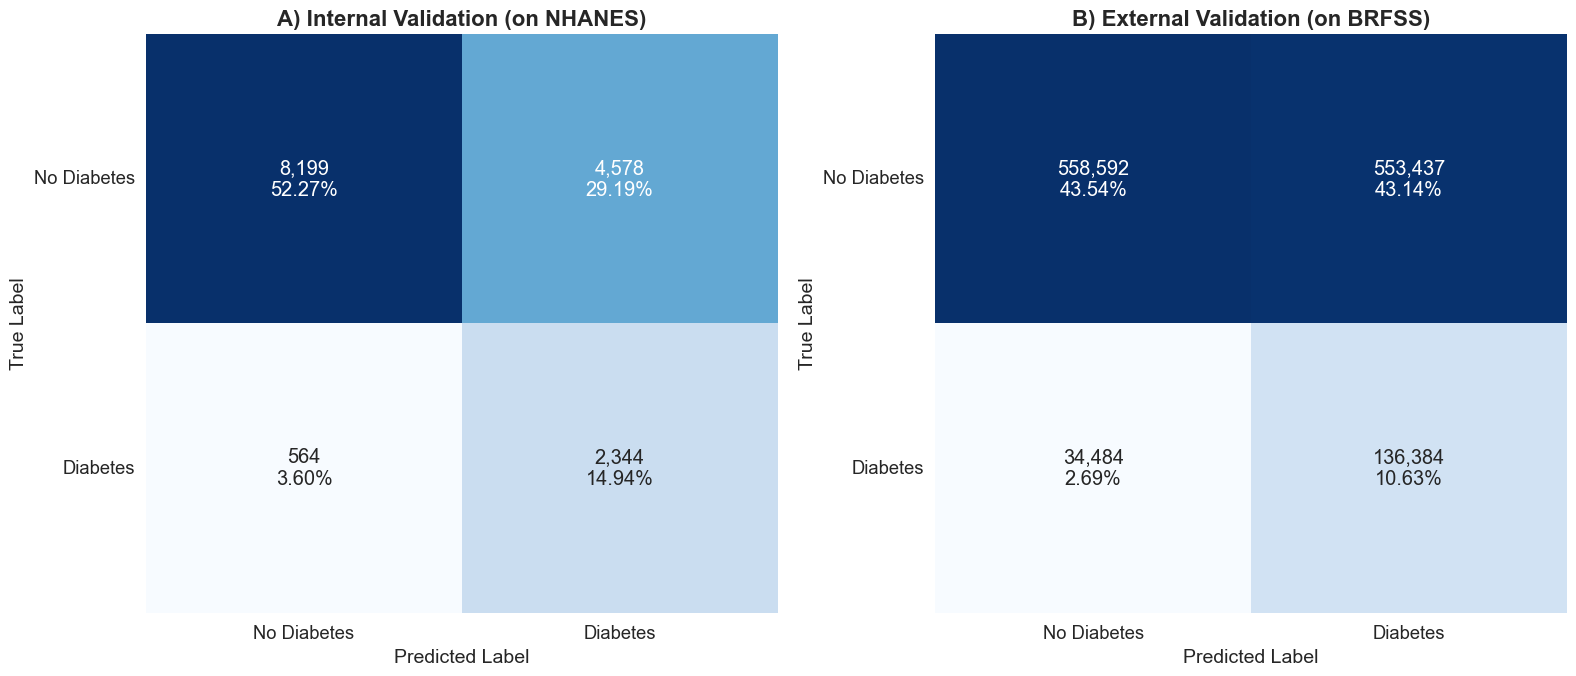


Publication-quality Figure 4 has been successfully saved to: ../reports\Figure_4_Confusion_Matrices.png


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

print("Generating Figure 4: Confusion Matrices (Publication Quality)...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)
internal_preds_path = r'C:\diabetes_prediction_project\notebooks\results\internal_validation_predictions.csv'
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_internal_all = pd.read_csv(internal_preds_path)
df_external = pd.read_csv(external_preds_path)
print("Successfully loaded prediction files.")

# --- 2. Prepare Data for Plotting ---
# Filter for XGBoost predictions only on the internal set
df_internal = df_internal_all[df_internal_all['model'] == 'XGBoost'].copy()

# Define the optimal threshold from your manuscript/feedback
optimal_threshold = 0.184

# Apply the threshold to get class predictions
df_internal['y_pred_class'] = (df_internal['y_pred_proba'] >= optimal_threshold).astype(int)
df_external['y_pred_class'] = (df_external['y_pred_proba'] >= optimal_threshold).astype(int)

# --- 3. Calculate Confusion Matrices ---
cm_internal = confusion_matrix(df_internal['y_true'], df_internal['y_pred_class'])
cm_external = confusion_matrix(df_external['y_true'], df_external['y_pred_class'])

# --- 4. Create a Helper Function for Plotting ---
def plot_confusion_matrix(cm, ax, title):
    """Helper function to plot an annotated confusion matrix."""
    group_counts = [f"{value:0,}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax, cbar=False)
    
    ax.set_title(title, fontsize=16, weight='bold')
    ax.set_xlabel('Predicted Label', fontsize=14)
    ax.set_ylabel('True Label', fontsize=14)
    ax.set_xticklabels(['No Diabetes', 'Diabetes'])
    ax.set_yticklabels(['No Diabetes', 'Diabetes'], rotation=0)

# --- 5. Generate the Two-Panel Figure ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_confusion_matrix(cm_internal, axes[0], 'A) Internal Validation (on NHANES)')
plot_confusion_matrix(cm_external, axes[1], 'B) External Validation (on BRFSS)')

plt.tight_layout()

# --- 6. Save the Figure ---
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_4_Confusion_Matrices.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 4 has been successfully saved to: {output_path}")

Generating Figure 4, Panel A: Internal Validation Confusion Matrix...


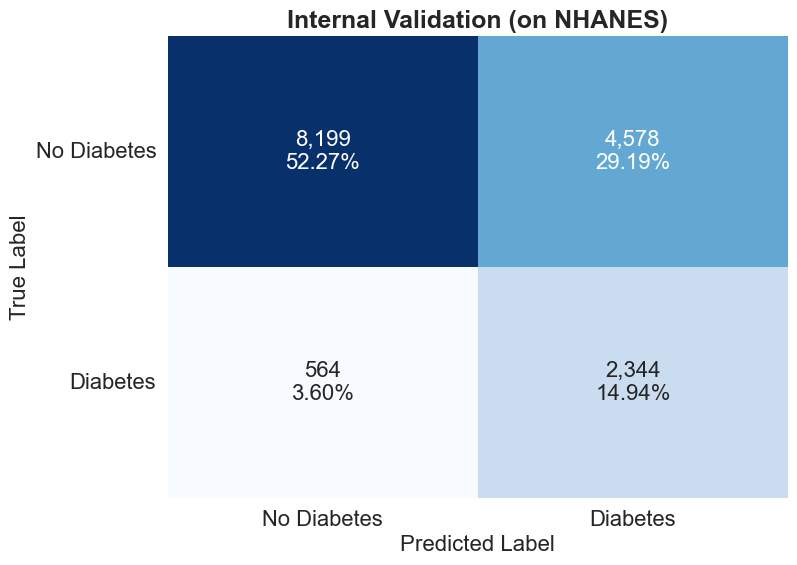

Panel A successfully saved to: ../reports\Figure_4A_Internal_CM.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

print("Generating Figure 4, Panel A: Internal Validation Confusion Matrix...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.8) # Larger font for a single plot
internal_preds_path = r'C:\diabetes_prediction_project\notebooks\results\internal_validation_predictions.csv'
df_internal_all = pd.read_csv(internal_preds_path)

# --- 2. Prepare Data ---
df_internal = df_internal_all[df_internal_all['model'] == 'XGBoost'].copy()
optimal_threshold = 0.184
df_internal['y_pred_class'] = (df_internal['y_pred_proba'] >= optimal_threshold).astype(int)
cm_internal = confusion_matrix(df_internal['y_true'], df_internal['y_pred_class'])

# --- 3. Plotting ---
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Create labels with counts and percentages
group_counts = [f"{value:0,}" for value in cm_internal.flatten()]
group_percentages = [f"{value:.2%}" for value in cm_internal.flatten() / np.sum(cm_internal)]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

sns.heatmap(cm_internal, annot=labels, fmt='', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 16})
ax.set_title('Internal Validation (on NHANES)', fontsize=18, weight='bold')
ax.set_xlabel('Predicted Label', fontsize=16)
ax.set_ylabel('True Label', fontsize=16)
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
ax.set_yticklabels(['No Diabetes', 'Diabetes'], rotation=0)

# --- 4. Save the Figure ---
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_4A_Internal_CM.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Panel A successfully saved to: {output_path}")


Generating Figure 4, Panel B: External Validation Confusion Matrix...


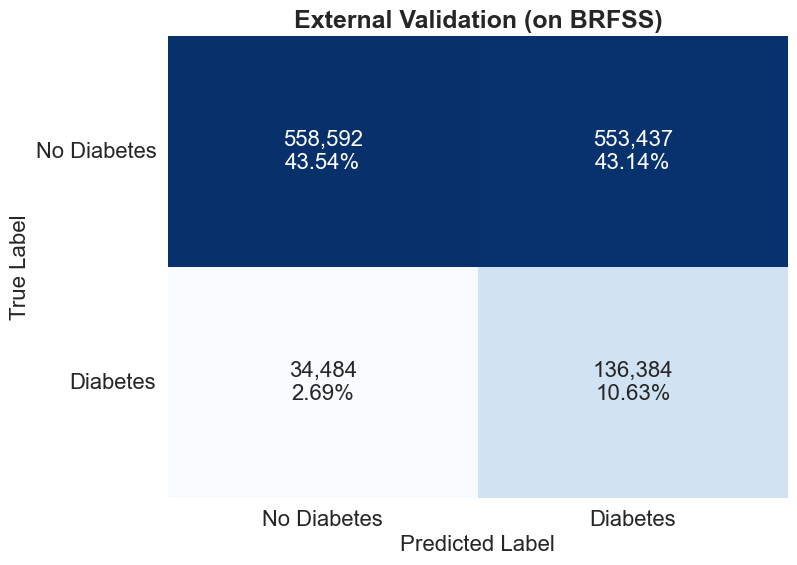

Panel B successfully saved to: ../reports\Figure_4B_External_CM.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

print("\nGenerating Figure 4, Panel B: External Validation Confusion Matrix...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.8)
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_external = pd.read_csv(external_preds_path)

# --- 2. Prepare Data ---
optimal_threshold = 0.184
df_external['y_pred_class'] = (df_external['y_pred_proba'] >= optimal_threshold).astype(int)
cm_external = confusion_matrix(df_external['y_true'], df_external['y_pred_class'])

# --- 3. Plotting ---
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Create labels with counts and percentages
group_counts = [f"{value:0,}" for value in cm_external.flatten()]
group_percentages = [f"{value:.2%}" for value in cm_external.flatten() / np.sum(cm_external)]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

sns.heatmap(cm_external, annot=labels, fmt='', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 16})
ax.set_title('External Validation (on BRFSS)', fontsize=18, weight='bold')
ax.set_xlabel('Predicted Label', fontsize=16)
ax.set_ylabel('True Label', fontsize=16)
ax.set_xticklabels(['No Diabetes', 'Diabetes'])
ax.set_yticklabels(['No Diabetes', 'Diabetes'], rotation=0)

# --- 4. Save the Figure ---
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_4B_External_CM.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Panel B successfully saved to: {output_path}")

Generating Figure 5: Precision-Recall Curves (Publication Quality)...
Successfully loaded prediction files.


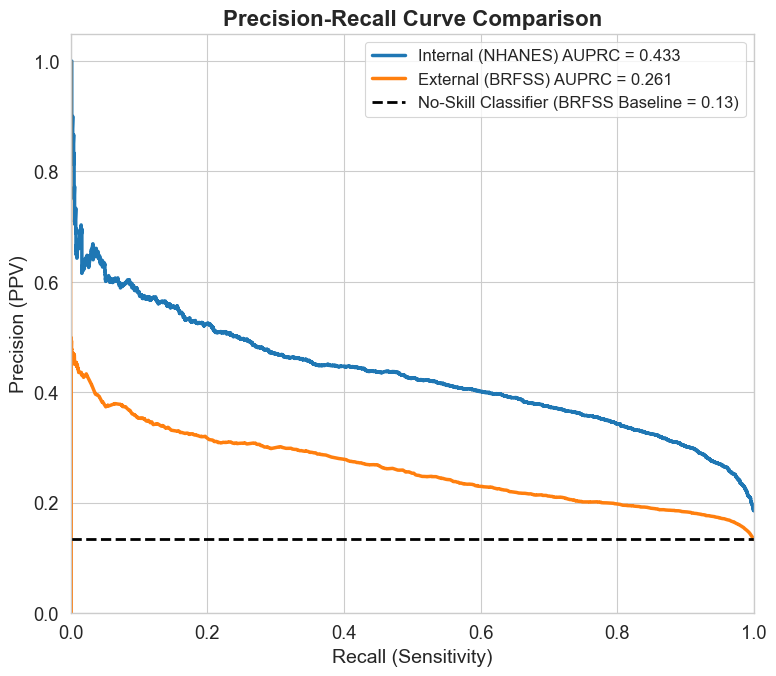


Publication-quality Figure 5 has been successfully saved to: ../reports\Figure_5_PR_Curves.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score
import os

print("Generating Figure 5: Precision-Recall Curves (Publication Quality)...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)
internal_preds_path = r'C:\diabetes_prediction_project\notebooks\results\internal_validation_predictions.csv'
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_internal_all = pd.read_csv(internal_preds_path)
df_external = pd.read_csv(external_preds_path)
print("Successfully loaded prediction files.")

# Filter for XGBoost predictions only
df_internal = df_internal_all[df_internal_all['model'] == 'XGBoost'].copy()

# --- 2. Calculate PR Curve Data ---
# Internal Validation (NHANES)
y_true_internal = df_internal['y_true']
y_pred_proba_internal = df_internal['y_pred_proba']
precision_internal, recall_internal, _ = precision_recall_curve(y_true_internal, y_pred_proba_internal)
auprc_internal = average_precision_score(y_true_internal, y_pred_proba_internal)
baseline_internal = y_true_internal.sum() / len(y_true_internal)

# External Validation (BRFSS)
y_true_external = df_external['y_true']
y_pred_proba_external = df_external['y_pred_proba']
precision_external, recall_external, _ = precision_recall_curve(y_true_external, y_pred_proba_external)
auprc_external = average_precision_score(y_true_external, y_pred_proba_external)
baseline_external = y_true_external.sum() / len(y_true_external)

# --- 3. Generate the Plot ---
plt.figure(figsize=(8, 7))
ax = plt.gca()

# Plot the PR curves
ax.plot(recall_internal, precision_internal, lw=2.5, color='#1f77b4',
        label=f'Internal (NHANES) AUPRC = {auprc_internal:.3f}')
ax.plot(recall_external, precision_external, lw=2.5, color='#ff7f0e',
        label=f'External (BRFSS) AUPRC = {auprc_external:.3f}')

# Plot the no-skill baseline
ax.axhline(baseline_external, color='k', linestyle='--', lw=2, 
           label=f'No-Skill Classifier (BRFSS Baseline = {baseline_external:.2f})')

# --- 4. Final Touches and Export ---
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=14)
ax.set_ylabel('Precision (PPV)', fontsize=14)
ax.set_title('Precision-Recall Curve Comparison', fontsize=16, weight='bold')
ax.legend(loc="upper right", fontsize=12)
ax.grid(True)

plt.tight_layout()

# Save the figure
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_5_PR_Curves.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 5 has been successfully saved to: {output_path}")

Generating Figure 6: Learning Curves (Publication Quality)...
Successfully loaded NHANES dataset.
Calculating learning curve scores... (This may take a few minutes)
Calculation complete.


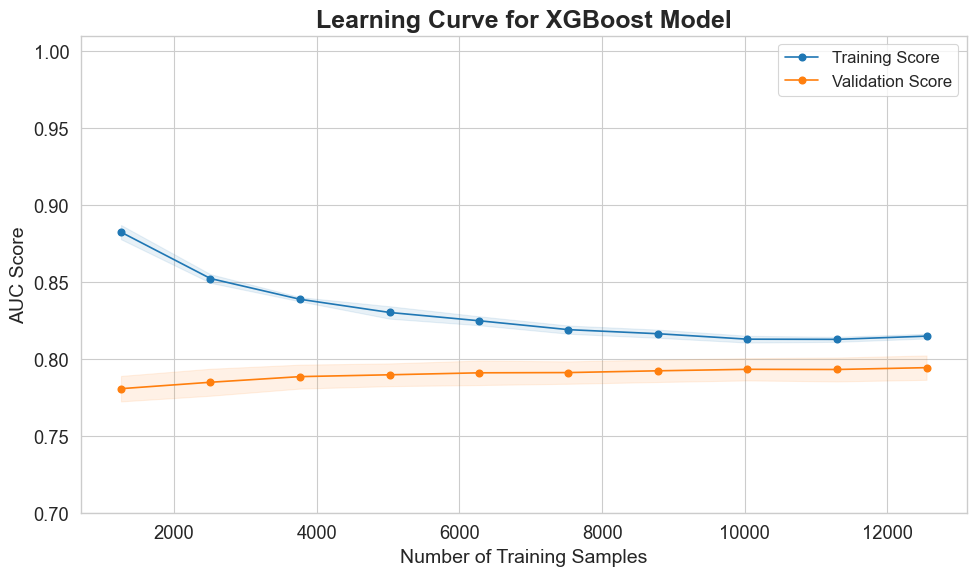


Publication-quality Figure 6 has been successfully saved to: ../reports\Figure_6_Learning_Curve.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import xgboost as xgb
import os

print("Generating Figure 6: Learning Curves (Publication Quality)...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
df_nhanes = pd.read_csv(nhanes_filepath)
df_nhanes.dropna(subset=['Diabetes_Outcome'], inplace=True)
print("Successfully loaded NHANES dataset.")

# --- 2. Prepare Data and Final Model ---
common_features = [
    'Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status',
    'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'
]
X = df_nhanes[common_features]
y = df_nhanes['Diabetes_Outcome']

# Define the final XGBoost model with manuscript's optimal hyperparameters
final_xgb = xgb.XGBClassifier(
    learning_rate=0.05, max_depth=3, n_estimators=200,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)

# Create a pipeline to handle imputation within the cross-validation process
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', final_xgb)
])

# --- 3. Generate Learning Curve Data ---
print("Calculating learning curve scores... (This may take a few minutes)")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10), # Use 10 points from 10% to 100% of the data
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1, # Use all available CPU cores
    random_state=42
)

# Calculate mean and standard deviation for plotting
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
validation_scores_std = np.std(validation_scores, axis=1)
print("Calculation complete.")

# --- 4. Generate the Plot ---
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Plot the mean scores
ax.plot(train_sizes, train_scores_mean, 'o-', color='#1f77b4', label='Training Score')
ax.plot(train_sizes, validation_scores_mean, 'o-', color='#ff7f0e', label='Validation Score')

# Plot the standard deviation as a shaded area (confidence band)
ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                train_scores_mean + train_scores_std, alpha=0.1, color='#1f77b4')
ax.fill_between(train_sizes, validation_scores_mean - validation_scores_std,
                validation_scores_mean + validation_scores_std, alpha=0.1, color='#ff7f0e')

# --- 5. Final Touches and Export ---
ax.set_title('Learning Curve for XGBoost Model', fontsize=18, weight='bold')
ax.set_xlabel('Number of Training Samples', fontsize=14)
ax.set_ylabel('AUC Score', fontsize=14)
ax.legend(loc='best', fontsize=12)
ax.grid(True)
ax.set_ylim(0.7, 1.01) # Zoom in on the relevant AUC range

plt.tight_layout()

# Save the figure
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_6_Learning_Curve.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 6 has been successfully saved to: {output_path}")

Generating Figure 7: Expanded Calibration Plot (Publication Quality)...
Successfully loaded external prediction file.


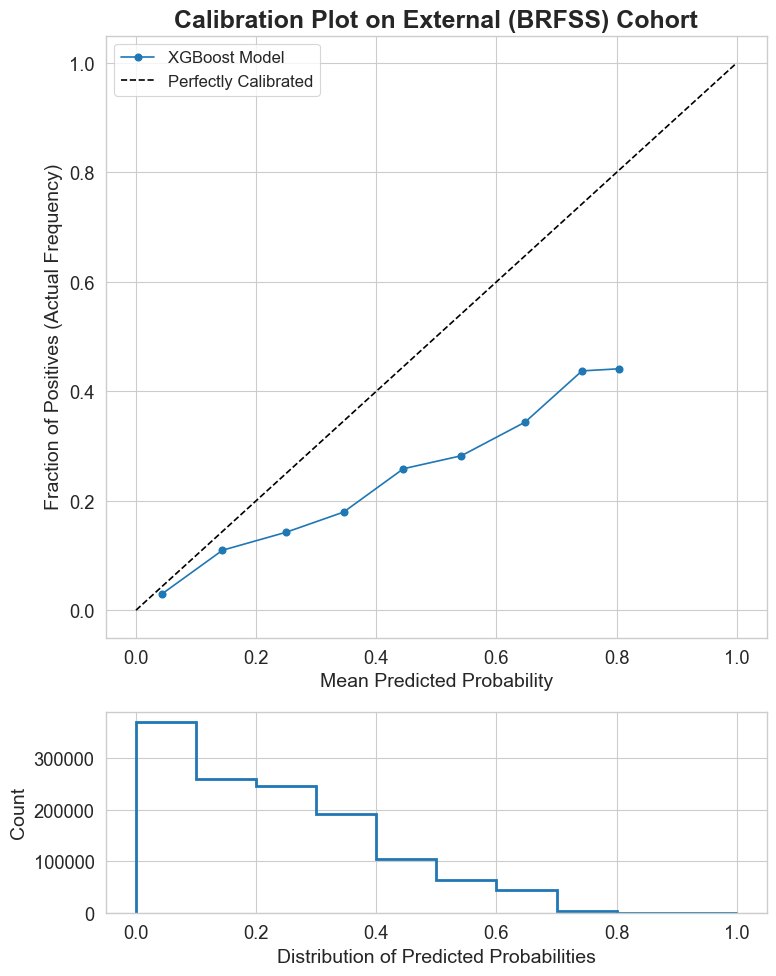


Publication-quality Figure 7 has been successfully saved to: ../reports\Figure_7_Calibration_Plot.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
import os

print("Generating Figure 7: Expanded Calibration Plot (Publication Quality)...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'

try:
    df_external = pd.read_csv(external_preds_path)
    print("Successfully loaded external prediction file.")
except FileNotFoundError as e:
    print(f"FATAL ERROR: Could not find the prediction file. {e}")
    raise e

y_true = df_external['y_true']
y_pred_proba = df_external['y_pred_proba']

# --- 2. Create a Figure with Two Stacked Subplots ---
# We create a grid with 2 rows and 1 column. The top plot will be larger.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})

# --- 3. Plot the Calibration Curve on the Top Subplot (ax1) ---
# Calculate the data for the calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_pred_proba, n_bins=10, strategy='uniform')

# Plot the model's calibration curve
ax1.plot(prob_pred, prob_true, marker='o', linestyle='-', label='XGBoost Model')
# Plot the perfectly calibrated line
ax1.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')

# Customize the top plot
ax1.set_title('Calibration Plot on External (BRFSS) Cohort', fontsize=18, weight='bold')
ax1.set_ylabel('Fraction of Positives (Actual Frequency)', fontsize=14)
ax1.set_xlabel('Mean Predicted Probability', fontsize=14)
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True)

# --- 4. Plot the Histogram on the Bottom Subplot (ax2) ---
ax2.hist(y_pred_proba, range=(0, 1), bins=10, histtype="step", lw=2)

# Customize the bottom plot
ax2.set_ylabel('Count', fontsize=14)
ax2.set_xlabel('Distribution of Predicted Probabilities', fontsize=14)
ax2.grid(True)

# --- 5. Final Touches and Export ---
plt.tight_layout()

output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_7_Calibration_Plot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 7 has been successfully saved to: {output_path}")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap
import os

print("Starting setup for Figure 8: Expanded SHAP Analysis...")

# --- 1. Load Data and Train Final Model ---
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
df_nhanes = pd.read_csv(nhanes_filepath)
df_brfss = pd.read_csv(brfss_filepath)
df_nhanes.dropna(subset=['Diabetes_Outcome'], inplace=True)
df_brfss.dropna(subset=['Diabetes_Outcome'], inplace=True)

common_features = [
    'Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status',
    'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'
]
X_train, y_train = df_nhanes[common_features], df_nhanes['Diabetes_Outcome']
X_test, y_test = df_brfss[common_features], df_brfss['Diabetes_Outcome']

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# --- THIS IS THE CORRECTED LINE ---
# We restore the original index from X_test to the new imputed DataFrame
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=common_features, index=X_test.index)
# --- END OF CORRECTION ---

final_xgb = xgb.XGBClassifier(
    learning_rate=0.05, max_depth=3, n_estimators=200,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
final_xgb.fit(X_train_imputed, y_train)
print("Final model trained.")

# --- 2. Calculate SHAP Values ---
# Now, X_test_sample will have the correct original index
X_test_sample = X_test_imputed_df.sample(5000, random_state=42)

print("Calculating SHAP values... (This may take a minute)")
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test_sample)
print("SHAP values calculated.")

# --- 3. Setup for Saving Plots ---
# Correctly go up one directory to find the 'reports' folder
output_dir = '../reports/Figure_8_Panels' 
os.makedirs(output_dir, exist_ok=True)
print(f"Setup complete. SHAP plots will be saved in '{output_dir}'.")

Starting setup for Figure 8: Expanded SHAP Analysis...
Final model trained.
Calculating SHAP values... (This may take a minute)
SHAP values calculated.
Setup complete. SHAP plots will be saved in '../reports/Figure_8_Panels'.


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:37:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Generating Panel A: SHAP Summary Plot...


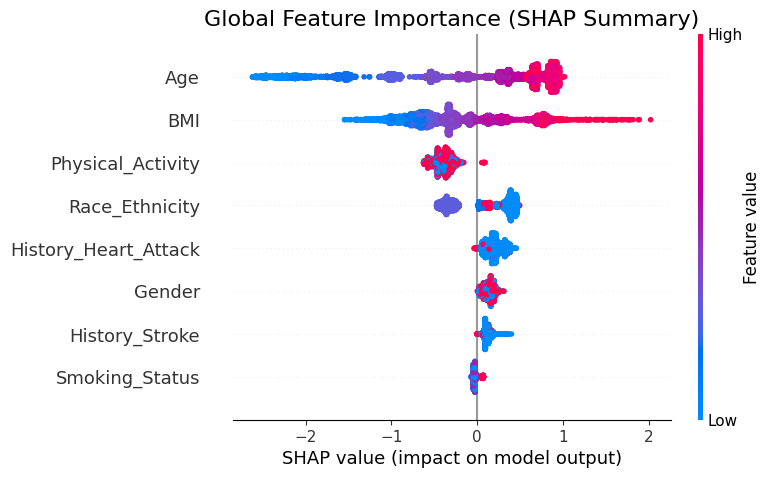

Saved: ../reports/Figure_8_Panels\Figure_8A_Summary_Plot.png


In [7]:
print("Generating Panel A: SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('Global Feature Importance (SHAP Summary)', fontsize=16)
output_path = os.path.join(output_dir, 'Figure_8A_Summary_Plot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")


Generating Panel B: SHAP Dependence Plot for Age...


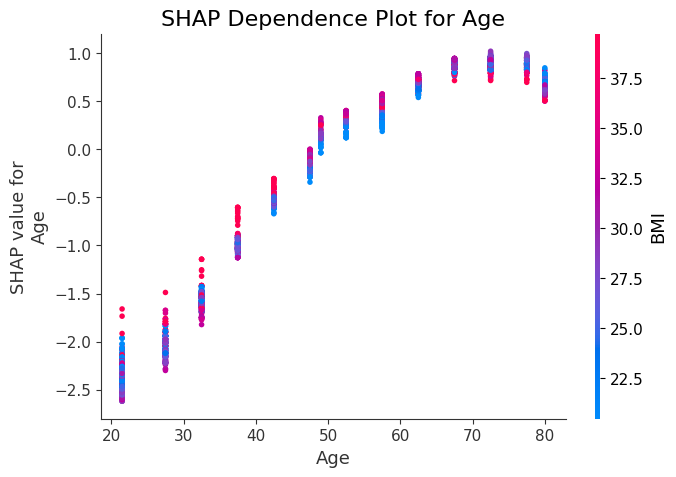

Saved: ../reports/Figure_8_Panels\Figure_8B_Dependence_Age.png


In [8]:
print("\nGenerating Panel B: SHAP Dependence Plot for Age...")
shap.dependence_plot('Age', shap_values, X_test_sample, interaction_index="BMI", show=False)
plt.title('SHAP Dependence Plot for Age', fontsize=16)
output_path = os.path.join(output_dir, 'Figure_8B_Dependence_Age.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")


Generating Panel C: SHAP Dependence Plot for BMI...


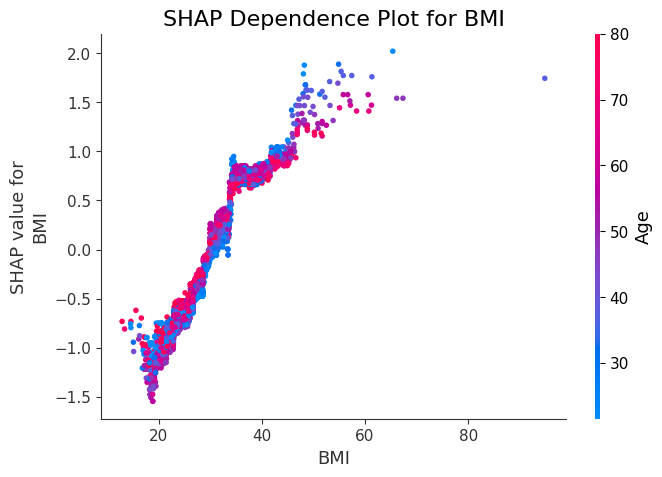

Saved: ../reports/Figure_8_Panels\Figure_8C_Dependence_BMI.png


In [9]:
print("\nGenerating Panel C: SHAP Dependence Plot for BMI...")
shap.dependence_plot('BMI', shap_values, X_test_sample, interaction_index="Age", show=False)
plt.title('SHAP Dependence Plot for BMI', fontsize=16)
output_path = os.path.join(output_dir, 'Figure_8C_Dependence_BMI.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved: {output_path}")


Generating Panel D: SHAP Force Plots...
Plotting True Positive example (Index: 8776)


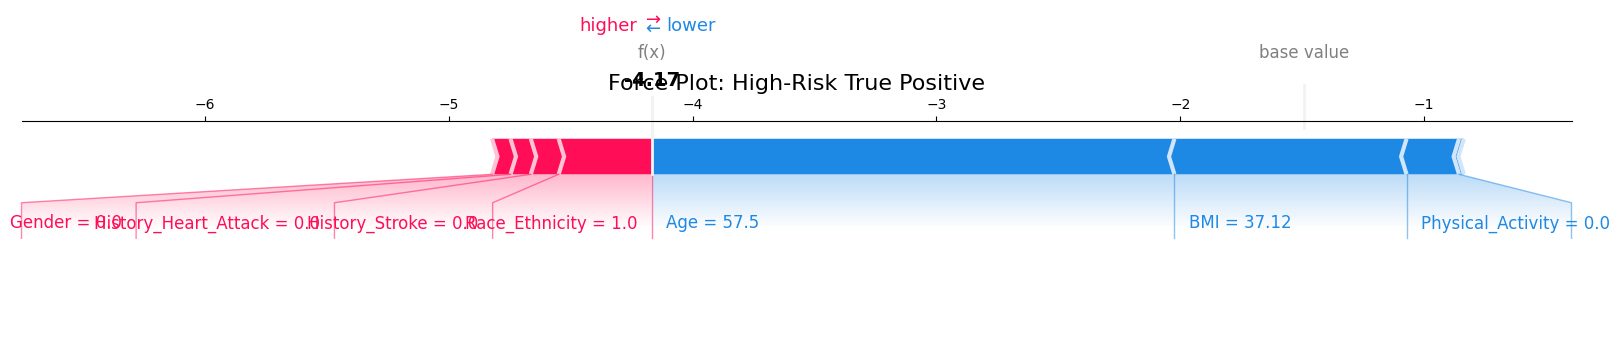

Saved: ../reports/Figure_8_Panels\Figure_8D_Force_Plot_TP.png

Plotting False Negative example (Index: 947495)


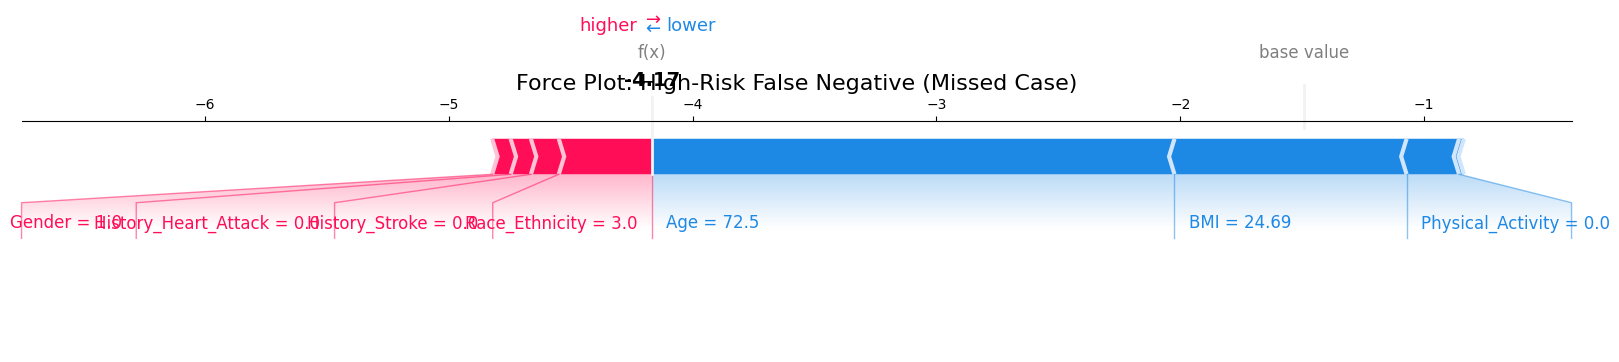

Saved: ../reports/Figure_8_Panels\Figure_8D_Force_Plot_FN.png


In [10]:
print("\nGenerating Panel D: SHAP Force Plots...")

# Add true labels and predictions to our sample for finding examples
y_test_sample = y_test.loc[X_test_sample.index]
y_pred_proba_sample = final_xgb.predict_proba(X_test_sample)[:, 1]

# Find a high-risk True Positive example
tp_examples = X_test_sample[(y_test_sample == 1) & (y_pred_proba_sample > 0.5)]
if not tp_examples.empty:
    tp_index = tp_examples.index[0]
    print(f"Plotting True Positive example (Index: {tp_index})")
    shap.force_plot(explainer.expected_value, shap_values[tp_examples.index.get_loc(tp_index), :], 
                    X_test_sample.loc[tp_index], matplotlib=True, show=False)
    plt.title('Force Plot: High-Risk True Positive', fontsize=16)
    output_path = os.path.join(output_dir, 'Figure_8D_Force_Plot_TP.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {output_path}")
else:
    print("Could not find a high-risk True Positive example in the sample.")

# Find a high-risk False Negative example
fn_examples = X_test_sample[(y_test_sample == 1) & (y_pred_proba_sample < 0.3)]
if not fn_examples.empty:
    fn_index = fn_examples.index[0]
    print(f"\nPlotting False Negative example (Index: {fn_index})")
    shap.force_plot(explainer.expected_value, shap_values[fn_examples.index.get_loc(fn_index), :], 
                    X_test_sample.loc[fn_index], matplotlib=True, show=False)
    plt.title('Force Plot: High-Risk False Negative (Missed Case)', fontsize=16)
    output_path = os.path.join(output_dir, 'Figure_8D_Force_Plot_FN.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {output_path}")
else:
    print("Could not find a suitable False Negative example in the sample.")

In [11]:
import shap

# --- This line is important. It loads the necessary JavaScript library for plotting ---
shap.initjs()

# --- Re-generate the True Positive (TP) Force Plot ---
print("Displaying Interactive Force Plot for True Positive case:")
# Note: We remove 'matplotlib=True' and 'show=False'
# This will return an interactive HTML plot directly in your notebook output.
shap.force_plot(explainer.expected_value, 
                shap_values[tp_examples.index.get_loc(tp_index), :], 
                X_test_sample.loc[tp_index])

Displaying Interactive Force Plot for True Positive case:


In [12]:
# --- Re-generate the False Negative (FN) Force Plot ---
print("\nDisplaying Interactive Force Plot for False Negative case:")
shap.force_plot(explainer.expected_value, 
                shap_values[fn_examples.index.get_loc(fn_index), :], 
                X_test_sample.loc[fn_index])


Displaying Interactive Force Plot for False Negative case:


Generating Figure 9: Fairness Analysis Forest Plot...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:48:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and predictions generated.
Subgroups created.
AUC calculations complete.


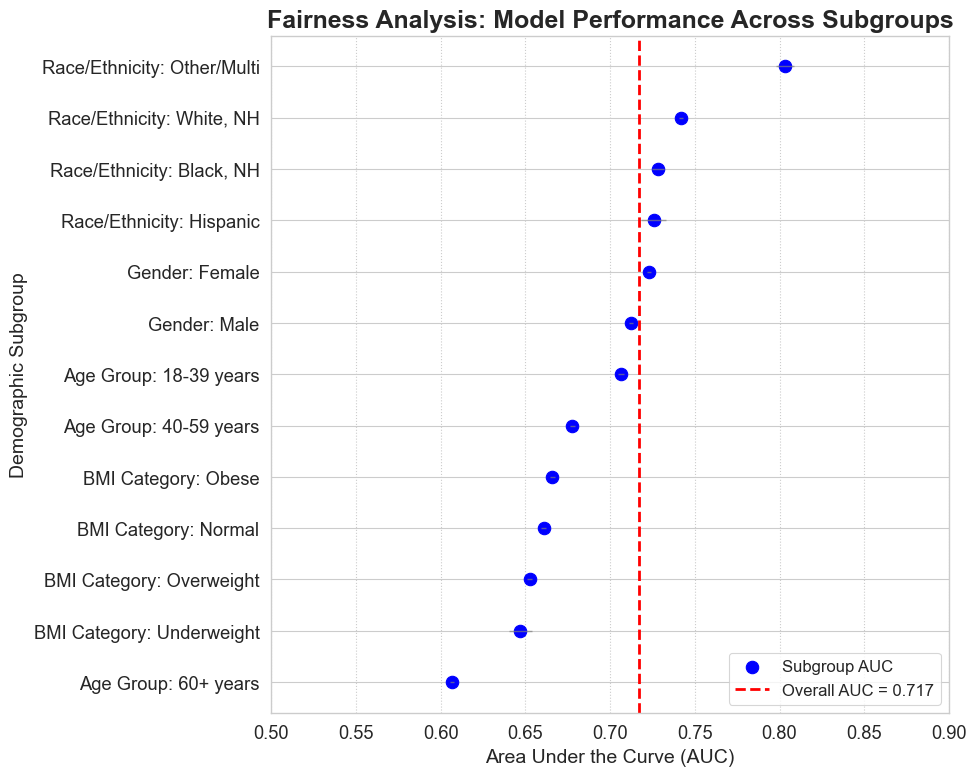


Publication-quality Figure 9 has been successfully saved to: ../reports\Figure_9_Fairness_Forest_Plot.png


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
import xgboost as xgb
import os

print("Generating Figure 9: Fairness Analysis Forest Plot...")

# --- 1. Setup, Load Data, and Get Predictions (Self-contained script) ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
df_nhanes = pd.read_csv(nhanes_filepath)
df_brfss = pd.read_csv(brfss_filepath)
df_nhanes.dropna(subset=['Diabetes_Outcome'], inplace=True)
df_brfss.dropna(subset=['Diabetes_Outcome'], inplace=True)

common_features = ['Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status', 'Physical_Activity', 'History_Heart_Attack', 'History_Stroke']
X_train, y_train = df_nhanes[common_features], df_nhanes['Diabetes_Outcome']
X_test, y_test = df_brfss[common_features], df_brfss['Diabetes_Outcome']

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

final_xgb = xgb.XGBClassifier(learning_rate=0.05, max_depth=3, n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
final_xgb.fit(X_train_imputed, y_train)
y_pred_proba = final_xgb.predict_proba(X_test_imputed)[:, 1]

df_brfss['y_true'] = y_test
df_brfss['y_pred_proba'] = y_pred_proba
print("Model trained and predictions generated.")

# --- 2. Create Subgroup Columns (as in Table 7) ---
df_brfss['Age Group'] = pd.cut(df_brfss['Age'], bins=[18, 39, 59, 120], labels=['18-39 years', '40-59 years', '60+ years'], right=True)
df_brfss['BMI Category'] = pd.cut(df_brfss['BMI'], bins=[0, 18.5, 25, 30, 200], labels=['Underweight', 'Normal', 'Overweight', 'Obese'], right=False)
df_brfss['Gender_label'] = df_brfss['Gender'].map({0: 'Female', 1: 'Male'})
df_brfss['Race_label'] = df_brfss['Race_Ethnicity'].map({1: 'White, NH', 2: 'Black, NH', 3: 'Hispanic', 4: 'Other/Multi'})
print("Subgroups created.")

# --- 3. Calculate AUC and CI for Each Subgroup ---
subgroup_analyses = [
    {'name': 'Gender', 'column': 'Gender_label'},
    {'name': 'Race/Ethnicity', 'column': 'Race_label'},
    {'name': 'Age Group', 'column': 'Age Group'},
    {'name': 'BMI Category', 'column': 'BMI Category'}
]
plot_data = []

for analysis in subgroup_analyses:
    col = analysis['column']
    for category in df_brfss[col].dropna().unique():
        sub_df = df_brfss[df_brfss[col] == category]
        n = len(sub_df)
        if n > 50 and len(sub_df['y_true'].unique()) > 1:
            auc = roc_auc_score(sub_df['y_true'], sub_df['y_pred_proba'])
            # Simplified CI calculation for visualization
            se_auc = np.sqrt(auc * (1 - auc) / n) 
            lower_ci, upper_ci = auc - 1.96 * se_auc, auc + 1.96 * se_auc
            plot_data.append({'Subgroup': f"{analysis['name']}: {category}", 'AUC': auc, 'Lower_CI': lower_ci, 'Upper_CI': upper_ci})

df_plot = pd.DataFrame(plot_data).sort_values(by='AUC').reset_index(drop=True)
overall_auc = roc_auc_score(df_brfss['y_true'], df_brfss['y_pred_proba'])
print("AUC calculations complete.")

# --- 4. Generate the Forest Plot ---
plt.figure(figsize=(10, 8))
# Plot the confidence interval lines
plt.hlines(y=df_plot.index, xmin=df_plot['Lower_CI'], xmax=df_plot['Upper_CI'], color='grey', alpha=0.7, lw=1)
# Plot the AUC points
plt.scatter(df_plot['AUC'], df_plot.index, color='blue', s=80, label='Subgroup AUC')
# Plot the overall AUC reference line
plt.axvline(x=overall_auc, color='red', linestyle='--', lw=2, label=f'Overall AUC = {overall_auc:.3f}')

# --- 5. Final Touches and Export ---
plt.yticks(df_plot.index, df_plot['Subgroup'])
plt.xlabel('Area Under the Curve (AUC)', fontsize=14)
plt.ylabel('Demographic Subgroup', fontsize=14)
plt.title('Fairness Analysis: Model Performance Across Subgroups', fontsize=18, weight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(axis='x', linestyle=':')
plt.xlim(0.5, 0.9) # Zoom in on the relevant AUC range

plt.tight_layout()
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_9_Fairness_Forest_Plot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 9 has been successfully saved to: {output_path}")

Generating Figure 10: Decision Curve Analysis (Publication Quality)...
Successfully loaded external prediction file.

Dataset: n=1,282,897, Prevalence=13.3%

=== Clinical Utility Metrics ===
At 10% threshold:
  XGBoost Net Benefit: 0.0601
  Treat All Net Benefit: 0.0378
  Additional benefit: 0.0223
  Per 1000 patients: 22.3 additional true positives

Model becomes harmful beyond: 20.3% threshold

✅ Publication-quality Figure 10 saved to: ../reports\Figure_10_DCA_Plot.png

=== Net Benefit Summary Table ===
Threshold XGBoost_NetBenefit TreatAll_NetBenefit AdditionalBenefit_per_1000
       5%             0.0944              0.0880                        6.4
      10%             0.0601              0.0378                       22.3
      15%             0.0293             -0.0181                       47.4
      20%             0.0017             -0.0809                       82.7

✅ Summary statistics saved to: ../reports\DCA_Summary_Statistics.csv


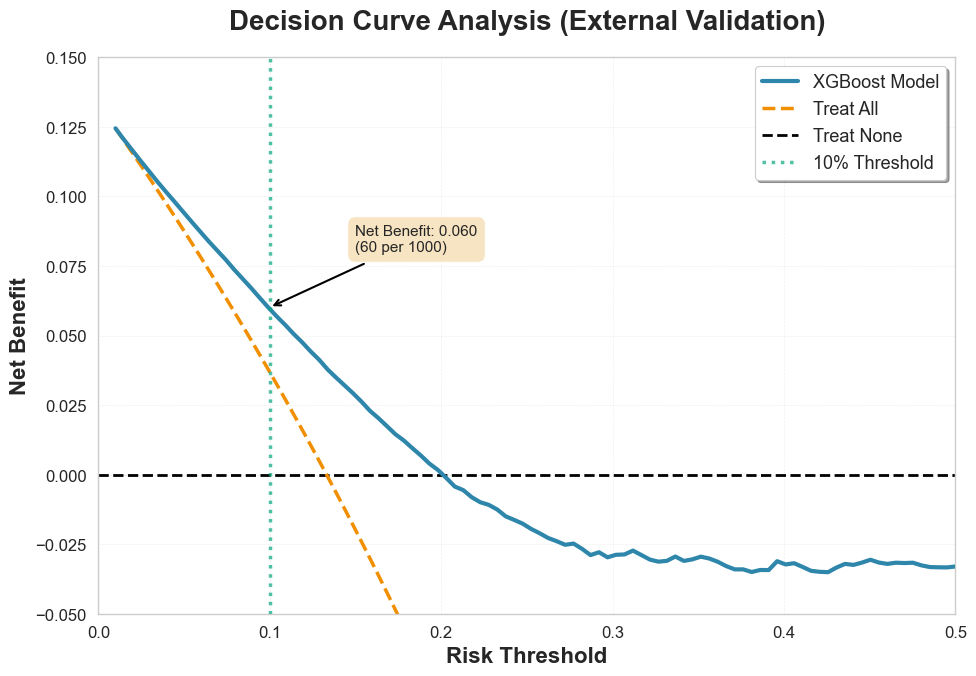


🎉 DCA Analysis Complete!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generating Figure 10: Decision Curve Analysis (Publication Quality)...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

# Load predictions for BOTH models
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'

try:
    df_external = pd.read_csv(external_preds_path)
    print("Successfully loaded external prediction file.")
except FileNotFoundError as e:
    print(f"FATAL ERROR: Could not find the prediction file. {e}")
    raise e

# Extract predictions
y_true = df_external['y_true']
y_pred_proba_xgb = df_external['y_pred_proba']  # XGBoost probabilities

# Check if Logistic Regression predictions exist
if 'y_pred_proba_lr' in df_external.columns:
    y_pred_proba_lr = df_external['y_pred_proba_lr']
    compare_lr = True
    print("Logistic Regression predictions found - will compare models.")
else:
    compare_lr = False
    print("WARNING: No LR predictions found. Only XGBoost will be plotted.")

n_total = len(y_true)
prevalence = np.mean(y_true)

print(f"\nDataset: n={n_total:,}, Prevalence={prevalence:.1%}")

# --- 2. Calculate Net Benefit Across Thresholds ---
thresholds = np.linspace(0.01, 0.5, 100)

def calculate_net_benefit(y_true, y_pred_proba, thresholds):
    """Calculate net benefit at each threshold."""
    net_benefits = []
    
    for thresh in thresholds:
        y_pred_class = (y_pred_proba >= thresh).astype(int)
        
        # Calculate TP and FP
        tp = np.sum((y_pred_class == 1) & (y_true == 1))
        fp = np.sum((y_pred_class == 1) & (y_true == 0))
        
        # Net Benefit formula: (TP/n) - (FP/n) × [thresh/(1-thresh)]
        net_benefit = (tp / n_total) - (fp / n_total) * (thresh / (1 - thresh))
        net_benefits.append(net_benefit)
    
    return np.array(net_benefits)

# Calculate net benefits
net_benefit_xgb = calculate_net_benefit(y_true, y_pred_proba_xgb, thresholds)

if compare_lr:
    net_benefit_lr = calculate_net_benefit(y_true, y_pred_proba_lr, thresholds)

# Treat All strategy
net_benefit_treat_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))

# --- 3. Find Key Clinical Metrics ---
# At 10% threshold
idx_10 = np.argmin(np.abs(thresholds - 0.10))
nb_xgb_10 = net_benefit_xgb[idx_10]
nb_treat_all_10 = net_benefit_treat_all[idx_10]

# Find where XGBoost crosses zero (becomes harmful)
zero_crossing_idx = np.where(net_benefit_xgb < 0)[0]
if len(zero_crossing_idx) > 0:
    harmful_threshold = thresholds[zero_crossing_idx[0]]
else:
    harmful_threshold = 0.5  # Beyond our range

print(f"\n=== Clinical Utility Metrics ===")
print(f"At 10% threshold:")
print(f"  XGBoost Net Benefit: {nb_xgb_10:.4f}")
print(f"  Treat All Net Benefit: {nb_treat_all_10:.4f}")
print(f"  Additional benefit: {(nb_xgb_10 - nb_treat_all_10):.4f}")
print(f"  Per 1000 patients: {(nb_xgb_10 - nb_treat_all_10)*1000:.1f} additional true positives")
print(f"\nModel becomes harmful beyond: {harmful_threshold:.1%} threshold")

if compare_lr:
    nb_lr_10 = net_benefit_lr[idx_10]
    print(f"  Logistic Regression Net Benefit: {nb_lr_10:.4f}")
    print(f"  XGBoost advantage over LR: {(nb_xgb_10 - nb_lr_10)*1000:.1f} per 1000 patients")

# --- 4. Generate the Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the curves with professional styling
ax.plot(thresholds, net_benefit_xgb, 
        lw=3, color='#2E86AB', label='XGBoost Model', zorder=3)

if compare_lr:
    ax.plot(thresholds, net_benefit_lr, 
            lw=2.5, color='#A23B72', linestyle='-', 
            label='Logistic Regression', alpha=0.8, zorder=2)

ax.plot(thresholds, net_benefit_treat_all, 
        lw=2.5, linestyle='--', color='#F18F01', 
        label='Treat All', zorder=2)

ax.axhline(0, color='#000000', linestyle='--', lw=2, 
           label='Treat None', zorder=1)

# Highlight the 10% threshold
ax.axvline(x=0.10, color='#06A77D', linestyle=':', lw=2.5, 
           label='10% Threshold', zorder=4, alpha=0.7)

# Add annotation at 10% threshold
ax.annotate(f'Net Benefit: {nb_xgb_10:.3f}\n({(nb_xgb_10*1000):.0f} per 1000)', 
            xy=(0.10, nb_xgb_10), 
            xytext=(0.15, nb_xgb_10 + 0.02),
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', 
                          color='black', lw=1.5))

# --- 5. Formatting ---
ax.set_xlim(0, 0.5)
ax.set_ylim(-0.05, 0.15)
ax.set_xlabel('Risk Threshold', fontsize=16, weight='bold')
ax.set_ylabel('Net Benefit', fontsize=16, weight='bold')
ax.set_title('Decision Curve Analysis (External Validation)', 
             fontsize=20, weight='bold', pad=20)

# Enhanced legend
ax.legend(loc='upper right', fontsize=13, frameon=True, 
          shadow=True, fancybox=True)

# Grid styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Tick formatting
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()

# --- 6. Save the Figure ---
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_10_DCA_Plot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✅ Publication-quality Figure 10 saved to: {output_path}")

# --- 7. Generate Summary Statistics Table ---
summary_stats = {
    'Threshold': ['5%', '10%', '15%', '20%'],
    'XGBoost_NetBenefit': [],
    'TreatAll_NetBenefit': [],
    'AdditionalBenefit_per_1000': []
}

for thresh_val in [0.05, 0.10, 0.15, 0.20]:
    idx = np.argmin(np.abs(thresholds - thresh_val))
    nb_xgb = net_benefit_xgb[idx]
    nb_all = net_benefit_treat_all[idx]
    additional = (nb_xgb - nb_all) * 1000
    
    summary_stats['XGBoost_NetBenefit'].append(f"{nb_xgb:.4f}")
    summary_stats['TreatAll_NetBenefit'].append(f"{nb_all:.4f}")
    summary_stats['AdditionalBenefit_per_1000'].append(f"{additional:.1f}")

summary_df = pd.DataFrame(summary_stats)
print("\n=== Net Benefit Summary Table ===")
print(summary_df.to_string(index=False))

# Save summary table
summary_path = os.path.join(output_dir, 'DCA_Summary_Statistics.csv')
summary_df.to_csv(summary_path, index=False)
print(f"\n✅ Summary statistics saved to: {summary_path}")

plt.show()

print("\n🎉 DCA Analysis Complete!")

Generating Figure 11: Hyperparameter Sensitivity Analysis...
Successfully loaded the XGBoost grid search results.


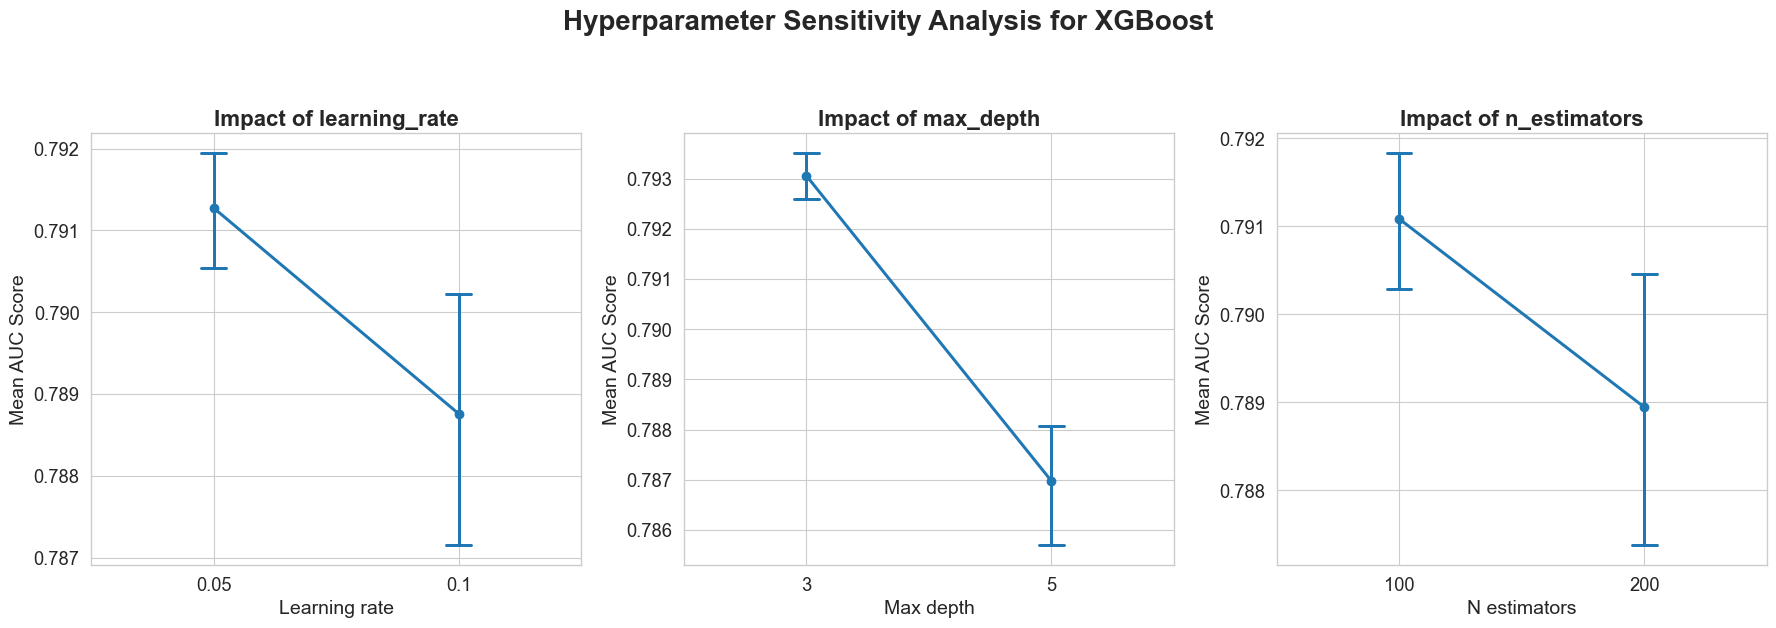


Publication-quality Figure 11 has been successfully saved to: ../reports\Figure_11_Hyperparameter_Sensitivity.png


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generating Figure 11: Hyperparameter Sensitivity Analysis...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

try:
    gs_filepath = r'C:\diabetes_prediction_project\notebooks\results\xgboost_grid_search_details.csv'
    df_gs_raw = pd.read_csv(gs_filepath)
    print("Successfully loaded the XGBoost grid search results.")
except FileNotFoundError as e:
    print(f"FATAL ERROR: Could not find the grid search file. {e}")
    raise e

# --- 2. Clean and Prepare the Data ---
# Remove repeated headers from the raw CSV file
df_cleaned = df_gs_raw[pd.to_numeric(df_gs_raw['mean_test_score'], errors='coerce').notna()].copy()
df_cleaned['mean_test_score'] = pd.to_numeric(df_cleaned['mean_test_score'])
# Rename columns for easier access
df_cleaned.rename(columns={
    'param_learning_rate': 'learning_rate',
    'param_max_depth': 'max_depth',
    'param_n_estimators': 'n_estimators'
}, inplace=True)

# --- 3. Create the Multi-Panel Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define the hyperparameters to plot
params_to_plot = ['learning_rate', 'max_depth', 'n_estimators']

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    # Use pointplot to show the mean and confidence interval for each parameter value
    sns.pointplot(data=df_cleaned, x=param, y='mean_test_score', ax=ax, capsize=0.1)
    
    ax.set_title(f'Impact of {param}', fontsize=16, weight='bold')
    ax.set_xlabel(param.replace('_', ' ').capitalize(), fontsize=14)
    ax.set_ylabel('Mean AUC Score', fontsize=14)
    ax.grid(True)

# --- 4. Final Touches and Export ---
fig.suptitle('Hyperparameter Sensitivity Analysis for XGBoost', fontsize=20, weight='bold', y=1.05)
plt.tight_layout()

# Save the figure
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_11_Hyperparameter_Sensitivity.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 11 has been successfully saved to: {output_path}")

Generating separate plots for Hyperparameter Sensitivity Analysis...
Successfully loaded the XGBoost grid search results.
Generating plot for learning_rate...


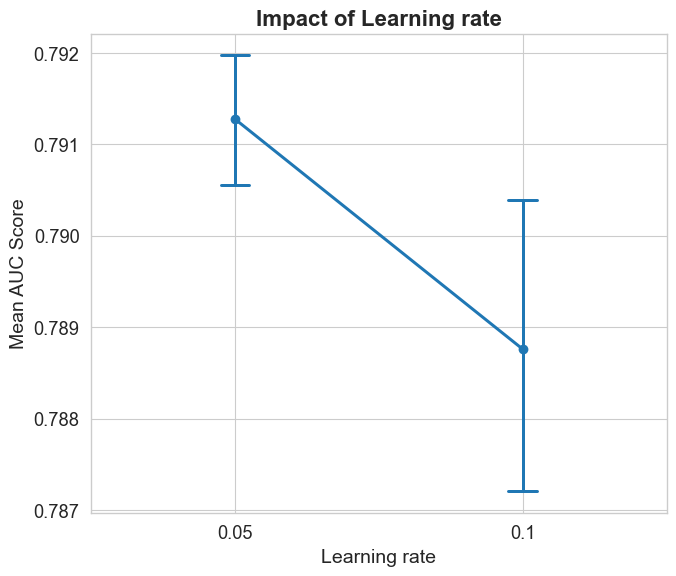

Saved: ../reports/Figure_11_Panels\Figure_11_learning_rate.png
Generating plot for max_depth...


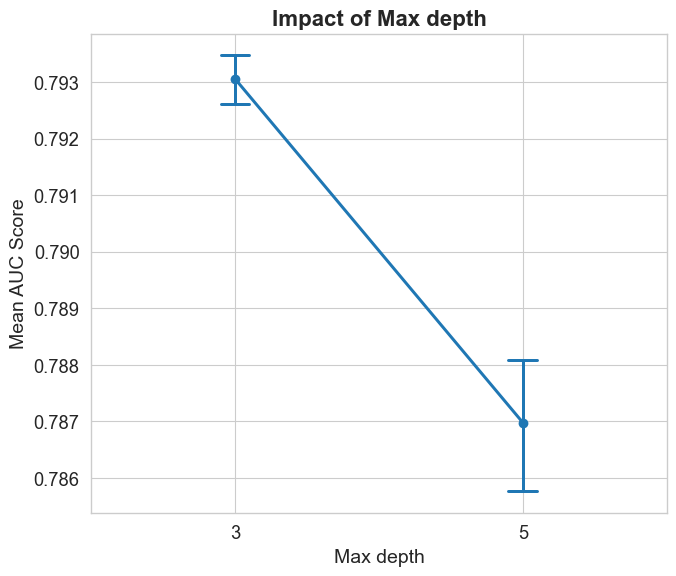

Saved: ../reports/Figure_11_Panels\Figure_11_max_depth.png
Generating plot for n_estimators...


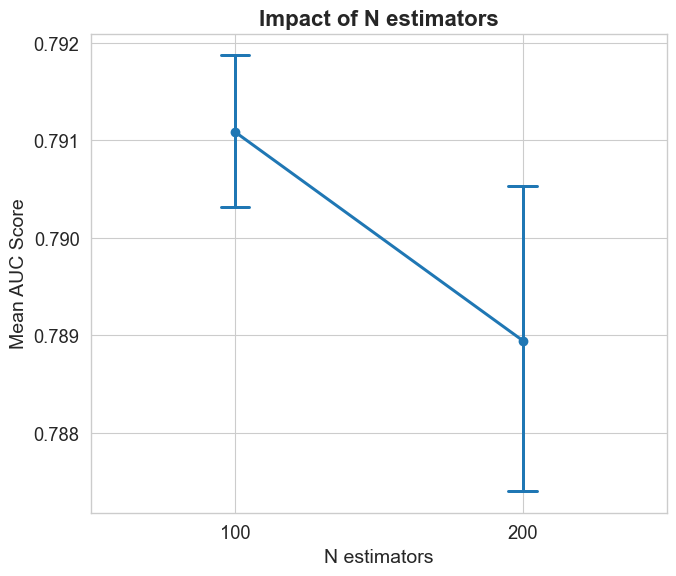

Saved: ../reports/Figure_11_Panels\Figure_11_n_estimators.png

All individual plots have been generated.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generating separate plots for Hyperparameter Sensitivity Analysis...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

try:
    gs_filepath = r'C:\diabetes_prediction_project\notebooks\results\xgboost_grid_search_details.csv'
    df_gs_raw = pd.read_csv(gs_filepath)
    print("Successfully loaded the XGBoost grid search results.")
except FileNotFoundError as e:
    print(f"FATAL ERROR: Could not find the grid search file. {e}")
    raise e

# --- 2. Clean and Prepare the Data ---
df_cleaned = df_gs_raw[pd.to_numeric(df_gs_raw['mean_test_score'], errors='coerce').notna()].copy()
df_cleaned['mean_test_score'] = pd.to_numeric(df_cleaned['mean_test_score'])
df_cleaned.rename(columns={
    'param_learning_rate': 'learning_rate', 'param_max_depth': 'max_depth',
    'param_n_estimators': 'n_estimators'
}, inplace=True)

# --- 3. Create a dedicated output folder ---
output_dir = '../reports/Figure_11_Panels'
os.makedirs(output_dir, exist_ok=True)

# --- 4. Generate and Save Each Plot Individually ---
params_to_plot = ['learning_rate', 'max_depth', 'n_estimators']

for param in params_to_plot:
    print(f"Generating plot for {param}...")
    plt.figure(figsize=(7, 6))
    ax = sns.pointplot(data=df_cleaned, x=param, y='mean_test_score', capsize=0.1)
    
    ax.set_title(f'Impact of {param.replace("_", " ").capitalize()}', fontsize=16, weight='bold')
    ax.set_xlabel(param.replace('_', ' ').capitalize(), fontsize=14)
    ax.set_ylabel('Mean AUC Score', fontsize=14)
    ax.grid(True)
    
    plt.tight_layout()
    
    # Save the individual figure
    output_path = os.path.join(output_dir, f'Figure_11_{param}.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close() # Close the figure to free up memory
    print(f"Saved: {output_path}")

print("\nAll individual plots have been generated.")

Generating Figure 12: Error Analysis and Misclassification Patterns...
Successfully loaded BRFSS data and external prediction file.
Classification outcomes defined.
Classification Outcome
True Negative     558592
False Positive    553437
True Positive     136384
False Negative     34484
Name: count, dtype: int64


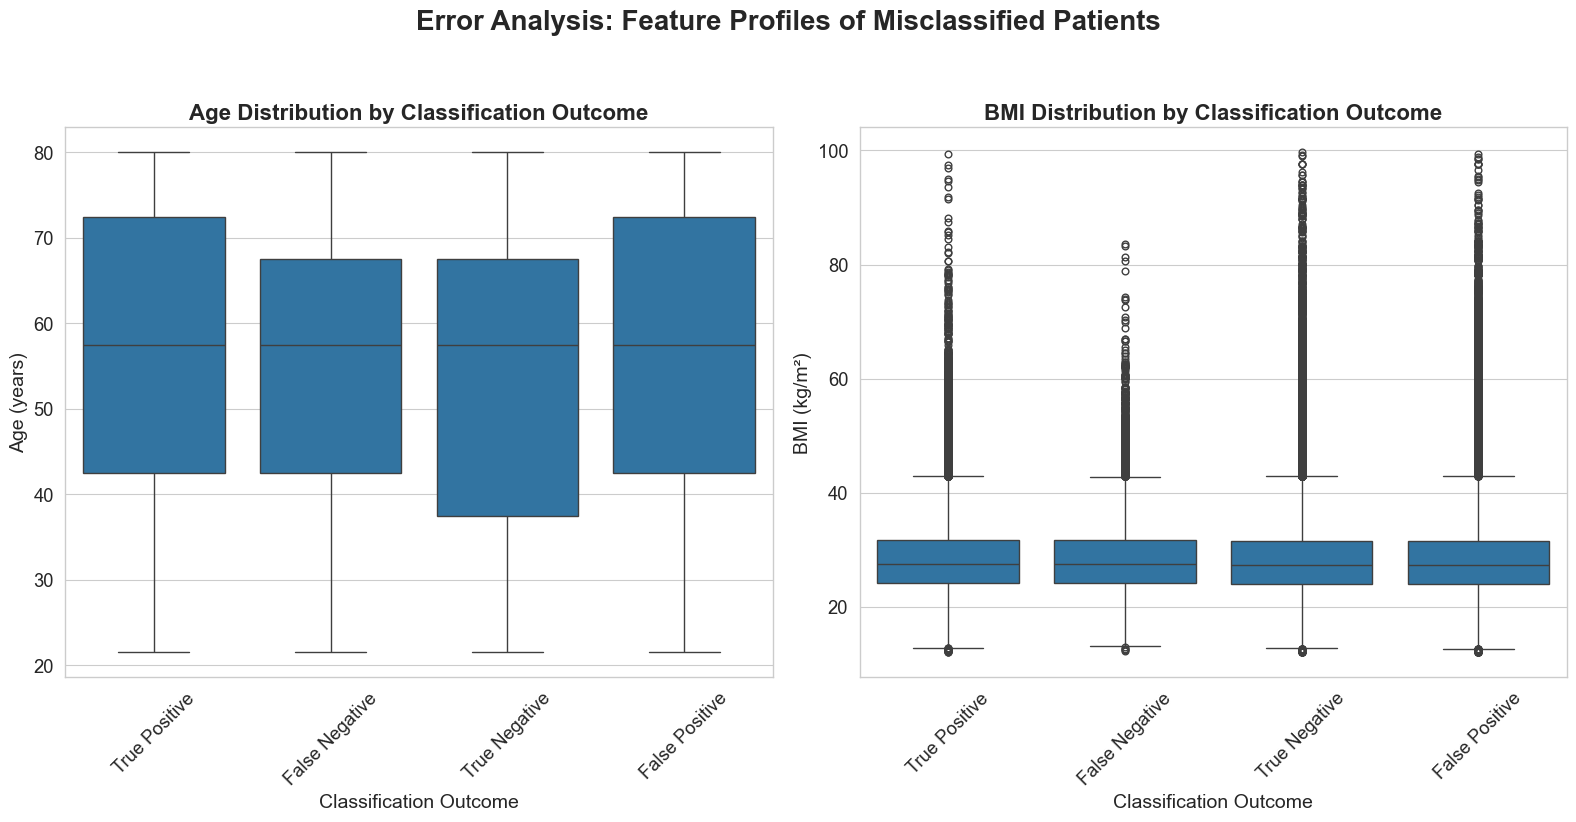


Publication-quality Figure 12 has been successfully saved to: ../reports\Figure_12_Error_Analysis.png


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generating Figure 12: Error Analysis and Misclassification Patterns...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'

try:
    df_brfss = pd.read_csv(brfss_filepath)
    df_preds = pd.read_csv(external_preds_path)
    print("Successfully loaded BRFSS data and external prediction file.")
except FileNotFoundError as e:
    print(f"FATAL ERROR: Could not find a required file. {e}")
    raise e

# Merge the features and predictions. We need to align them by their index.
df_analysis = df_brfss.reset_index().merge(df_preds.reset_index(), on='index')

# --- 2. Create the Classification Outcome Column ---
optimal_threshold = 0.184
y_true = df_analysis['y_true']
y_pred = (df_analysis['y_pred_proba'] >= optimal_threshold).astype(int)

conditions = [
    (y_true == 1) & (y_pred == 1), # True Positive
    (y_true == 1) & (y_pred == 0), # False Negative
    (y_true == 0) & (y_pred == 0), # True Negative
    (y_true == 0) & (y_pred == 1)  # False Positive
]
outcomes = ['True Positive', 'False Negative', 'True Negative', 'False Positive']

# --- THIS IS THE CORRECTED LINE ---
# We provide a text-based default value to match the data type of 'outcomes'.
df_analysis['Classification Outcome'] = np.select(conditions, outcomes, default='Unclassified')
# --- END OF CORRECTION ---

print("Classification outcomes defined.")
# Let's check the distribution to make sure everything was classified
print(df_analysis['Classification Outcome'].value_counts())


# --- 3. Generate the Two-Panel Figure ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Panel A: Age Distribution by Outcome ---
ax = axes[0]
sns.boxplot(data=df_analysis, x='Classification Outcome', y='Age', ax=ax,
            order=['True Positive', 'False Negative', 'True Negative', 'False Positive'])
ax.set_title('Age Distribution by Classification Outcome', fontsize=16, weight='bold')
ax.set_xlabel('Classification Outcome', fontsize=14)
ax.set_ylabel('Age (years)', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# --- Panel B: BMI Distribution by Outcome ---
ax = axes[1]
sns.boxplot(data=df_analysis, x='Classification Outcome', y='BMI', ax=ax,
            order=['True Positive', 'False Negative', 'True Negative', 'False Positive'])
ax.set_title('BMI Distribution by Classification Outcome', fontsize=16, weight='bold')
ax.set_xlabel('Classification Outcome', fontsize=14)
ax.set_ylabel('BMI (kg/m²)', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# --- 4. Final Touches and Export ---
fig.suptitle('Error Analysis: Feature Profiles of Misclassified Patients', fontsize=20, weight='bold', y=1.03)
plt.tight_layout()

# Save the figure
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_12_Error_Analysis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"\nPublication-quality Figure 12 has been successfully saved to: {output_path}")

Generating Figure 12, Panel A: Age Error Analysis...


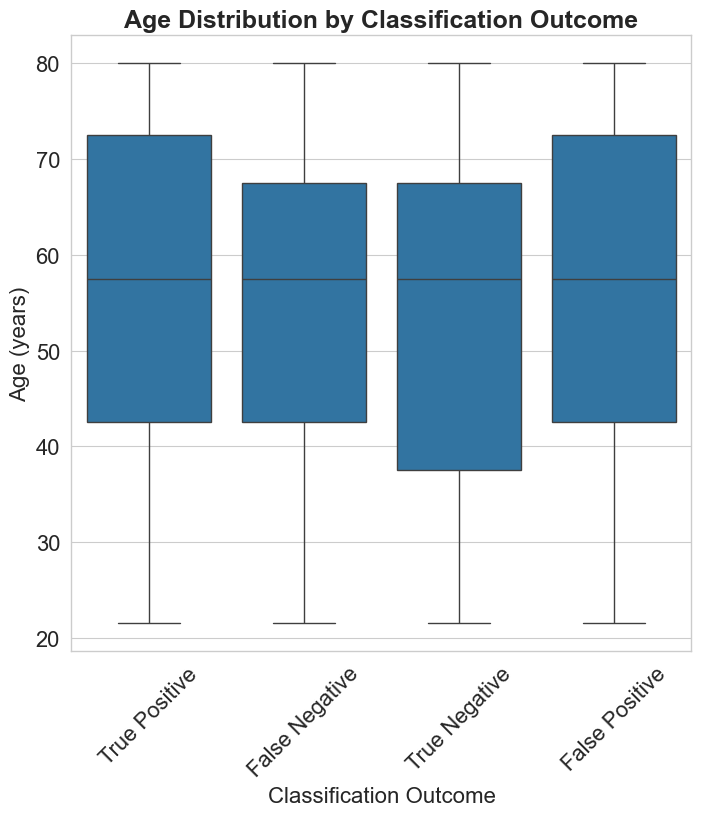

Panel A successfully saved to: ../reports\Figure_12A_Error_Analysis_Age.png


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generating Figure 12, Panel A: Age Error Analysis...")

# --- 1. Setup & Load Data (Self-contained for clarity) ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.8) # Larger font for a single plot

brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_brfss = pd.read_csv(brfss_filepath)
df_preds = pd.read_csv(external_preds_path)
df_analysis = df_brfss.reset_index().merge(df_preds.reset_index(), on='index')

# --- 2. Create Classification Outcome Column ---
optimal_threshold = 0.184
y_true = df_analysis['y_true']
y_pred = (df_analysis['y_pred_proba'] >= optimal_threshold).astype(int)
conditions = [
    (y_true == 1) & (y_pred == 1), (y_true == 1) & (y_pred == 0),
    (y_true == 0) & (y_pred == 0), (y_true == 0) & (y_pred == 1)
]
outcomes = ['True Positive', 'False Negative', 'True Negative', 'False Positive']
df_analysis['Classification Outcome'] = np.select(conditions, outcomes, default='Unclassified')

# --- 3. Plotting Panel A ---
plt.figure(figsize=(8, 8))
ax = sns.boxplot(data=df_analysis, x='Classification Outcome', y='Age',
                 order=['True Positive', 'False Negative', 'True Negative', 'False Positive'])
ax.set_title('Age Distribution by Classification Outcome', fontsize=18, weight='bold')
ax.set_xlabel('Classification Outcome', fontsize=16)
ax.set_ylabel('Age (years)', fontsize=16)
ax.tick_params(axis='x', rotation=45)

# --- 4. Save the Figure ---
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_12A_Error_Analysis_Age.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Panel A successfully saved to: {output_path}")


Generating Figure 12, Panel B: BMI Error Analysis...


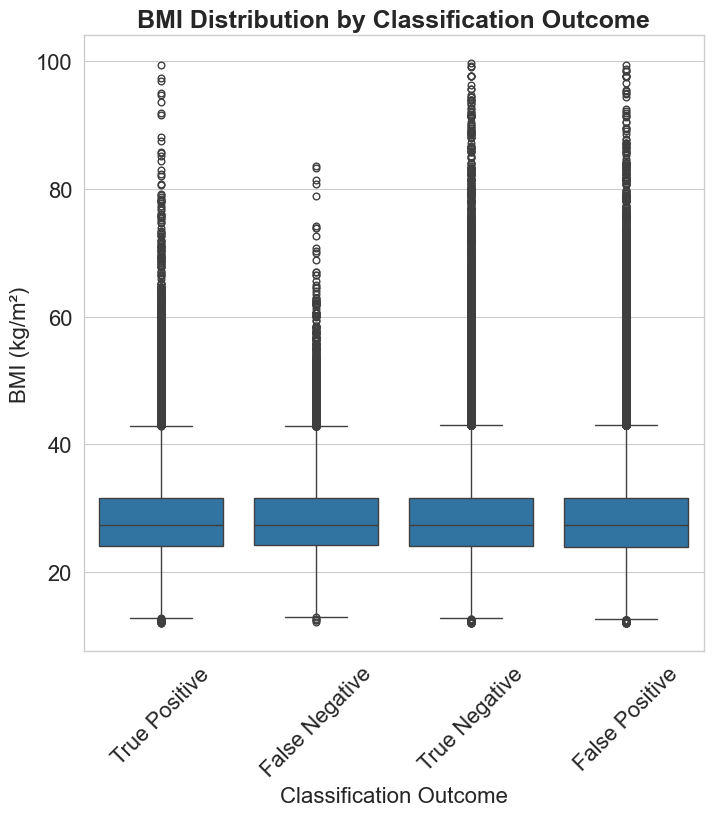

Panel B successfully saved to: ../reports\Figure_12B_Error_Analysis_BMI.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("\nGenerating Figure 12, Panel B: BMI Error Analysis...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.8)
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_brfss = pd.read_csv(brfss_filepath)
df_preds = pd.read_csv(external_preds_path)
df_analysis = df_brfss.reset_index().merge(df_preds.reset_index(), on='index')

# --- 2. Create Classification Outcome Column ---
optimal_threshold = 0.184
y_true = df_analysis['y_true']
y_pred = (df_analysis['y_pred_proba'] >= optimal_threshold).astype(int)
conditions = [
    (y_true == 1) & (y_pred == 1), (y_true == 1) & (y_pred == 0),
    (y_true == 0) & (y_pred == 0), (y_true == 0) & (y_pred == 1)
]
outcomes = ['True Positive', 'False Negative', 'True Negative', 'False Positive']
df_analysis['Classification Outcome'] = np.select(conditions, outcomes, default='Unclassified')

# --- 3. Plotting Panel B ---
plt.figure(figsize=(8, 8))
ax = sns.boxplot(data=df_analysis, x='Classification Outcome', y='BMI',
                 order=['True Positive', 'False Negative', 'True Negative', 'False Positive'])
ax.set_title('BMI Distribution by Classification Outcome', fontsize=18, weight='bold')
ax.set_xlabel('Classification Outcome', fontsize=16)
ax.set_ylabel('BMI (kg/m²)', fontsize=16)
ax.tick_params(axis='x', rotation=45)

# --- 4. Save the Figure ---
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Figure_12B_Error_Analysis_BMI.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"Panel B successfully saved to: {output_path}")